# Statistical Analysis of Multi-Scale Bayesian Optimization Results

Generates statistical tests, summary tables, and publication figures for the bilevel BO paper.

**Sections:**
0. Setup & Configuration
1. Data Loading
2. Per-Problem Statistical Tests (Wilcoxon, effect sizes, Holm-Bonferroni)
3. Summary Tables (LaTeX-ready, hyperparameter sensitivity, NLP comparison)
4. Reproduced Publication Figures (Figs 2-7)
5. New Statistical Figures (forest plot, boxplots, wall time, significance matrix)
6. Paper Claims Validation
7. Export

In [1]:
import sys
import re
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from pathlib import Path
from collections import defaultdict
from scipy.stats import (wilcoxon, friedmanchisquare, rankdata, spearmanr,
                         binomtest)

warnings.filterwarnings('ignore')

# -- Add repo root to path --------------------------------------------------
REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

from utils import REPORT_FIGS_DIR
from functions import get_all_problems

# Per-iteration result files live in results_parallel/:
#   {Problem}_ninit{N}_xi{X}_it{rep}.pkl
RESULTS_DIR = REPO_ROOT / 'results_parallel'

# -- Publication-quality matplotlib settings (from figures.ipynb) -----------
matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'mathtext.fontset': 'dejavusans',
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'lines.linewidth': 1.0,
    'lines.markersize': 4,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.minor.width': 0.4,
    'ytick.minor.width': 0.4,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'xtick.minor.size': 1.5,
    'ytick.minor.size': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'axes.grid': False,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.02,
    'figure.dpi': 150,
})

# Column widths (inches)
COL1 = 3.5
COL2 = 7.0

# Colour palette
C_NLP  = '#474747'
C_BBBO = '#0C5DA5'
C_BIBO = '#FF2C00'
C_DE   = '#029E73'
C_FILL = 0.18

ANIMATE = False

print(f'RESULTS_DIR: {RESULTS_DIR}')
print(f'REPORT_FIGS_DIR: {REPORT_FIGS_DIR}')
print('Setup complete.')

RESULTS_DIR: c:\Users\jhamm\OneDrive - The University of Texas at Austin\business\UTexas\projects\Greybox Multi-scale Optimization\results_parallel
REPORT_FIGS_DIR: C:\Users\jhamm\OneDrive - The University of Texas at Austin\business\UTexas\projects\Greybox Multi-scale Optimization\Report\figs
Setup complete.


In [2]:
# -- Problem metadata and short names --
all_probs = get_all_problems()

short_map = {
    'Small-Feasible-Region': 'SFR-1', 'Small-Feasible-Region-2': 'SFR-2',
    'Rastrigin': 'Rast.', 'Toy-Hydrology': 'Hydro.',
    'Rosen-Suzuki': 'R-S', 'CSTR': 'CSTR',
    'Heat-Exchanger': 'HEN', 'PSA': 'PSA',
    'Batch-Reactor': 'Batch', 'Distillation': 'Distill.',
    'Evaporator': 'Evap.', 'Membrane': 'Memb.',
    'Williams-Otto': 'W-O',
}

PROB_META = {}
for pname, p in all_probs.items():
    PROB_META[pname] = {
        'n_wb': p.n_x_wb, 'n_bb': p.n_x_bb, 'n_y': p.n_y, 'n_g': p.n_g,
        'total': p.n_x_wb + p.n_x_bb,
        'short': short_map.get(pname, pname),
    }

# PROBLEM_ORDER and SHORT_NAMES will be finalized after data loading
# (only problems with results will be included)
print(f'{len(all_probs)} problems defined in functions.py')

13 problems defined in functions.py


---
## 1. Data Loading

Dynamically scan `results_parallel/` for individual iteration files
`{Problem}_ninit{N}_xi{X}_it{rep}.pkl`, merge repetitions per
`(problem, n_init, xi)` combination, and determine the best xi per problem
(lowest mean Bi-BO final regret).

In [3]:
# -- Load per-iteration result files from results_parallel/ ----------------
# File pattern: {Problem}_ninit{N}_xi{X}_it{rep}.pkl
# Each file holds settings + results for one (problem, n_init, xi, rep).
# Bi-level BO has TWO inner-solver variants:
#   bilevel_bo_ei_multistart  ->  multistart SLSQP
#   bilevel_bo_ei_global      ->  basin hopping (BH)

def _merge_solver_dicts(accumulated, single):
    """Append all list-valued entries from single into accumulated."""
    for k, v in single.items():
        if isinstance(v, list):
            accumulated.setdefault(k, []).extend(v)
        elif k not in accumulated:
            accumulated[k] = v


all_data = {}              # (problem, n_init, xi) -> {settings, results: {prob: {...}}}
all_problems_found = set()
all_ninit_found = set()
all_xi_found = set()

IT_PATTERN = re.compile(r'^(.+)_ninit(\d+)_xi([\d.]+)_it(\d+)\.pkl$')

file_groups = defaultdict(list)
for fpath in sorted(RESULTS_DIR.glob('*_it*.pkl')):
    m = IT_PATTERN.match(fpath.name)
    if not m:
        continue
    prob_name = m.group(1)
    ni = int(m.group(2))
    xi = float(m.group(3))
    rep = int(m.group(4))
    file_groups[(prob_name, ni, xi)].append((rep, fpath))
    all_problems_found.add(prob_name)
    all_ninit_found.add(ni)
    all_xi_found.add(xi)

for key, rep_files in file_groups.items():
    prob_name, ni, xi = key
    rep_files.sort(key=lambda x: x[0])

    merged_settings = None
    merged_solvers = {}
    scalar_fields = {}

    for rep_idx, fpath in rep_files:
        with open(fpath, 'rb') as f:
            d = pickle.load(f)
        if merged_settings is None:
            merged_settings = d['settings'].copy()

        prob_results = d['results'][prob_name]
        for rk, rv in prob_results.items():
            if isinstance(rv, dict):
                merged_solvers.setdefault(rk, {})
                _merge_solver_dicts(merged_solvers[rk], rv)
            else:
                scalar_fields[rk] = rv

    combined_results = {**scalar_fields, **merged_solvers}
    merged_settings['n_repetitions'] = len(rep_files)
    if 'rep_index' in merged_settings:
        del merged_settings['rep_index']

    all_data[key] = {
        'settings': merged_settings,
        'results': {prob_name: combined_results},
    }

print(f'Loaded {sum(len(v) for v in file_groups.values())} per-iteration files '
      f'-> {len(all_data)} merged (problem, n_init, xi) groups')

ninit_values = sorted(all_ninit_found)
xi_values = sorted(all_xi_found)

# -- Detect which Bi-BO inner-solver variants are present in the data ------
# Each variant: (label, results-dict key, default plot color)
ALL_BIBO_VARIANTS = [
    ('Bi-BO (SLSQP)', 'bilevel_bo_ei_multistart', '#FF2C00'),
    ('Bi-BO (BH)',    'bilevel_bo_ei_global',    '#FFA500'),
]
_present_keys = set()
for d in all_data.values():
    for prob_dict in d['results'].values():
        _present_keys.update(prob_dict.keys())
BIBO_VARIANTS = [v for v in ALL_BIBO_VARIANTS if v[1] in _present_keys]
BIBO_KEYS    = [v[1] for v in BIBO_VARIANTS]
BIBO_LABELS  = [v[0] for v in BIBO_VARIANTS]
BIBO_COLORS  = {v[1]: v[2] for v in BIBO_VARIANTS}

print(f'Problems ({len(all_problems_found)}): {sorted(all_problems_found)}')
print(f'n_init values: {ninit_values}')
print(f'xi values: {xi_values}')
print(f'Bi-BO variants present: {BIBO_LABELS}')

Loaded 2730 per-iteration files -> 273 merged (problem, n_init, xi) groups
Problems (13): ['Batch-Reactor', 'CSTR', 'Distillation', 'Evaporator', 'Heat-Exchanger', 'Membrane', 'PSA', 'Rastrigin', 'Rosen-Suzuki', 'Small-Feasible-Region', 'Small-Feasible-Region-2', 'Toy-Hydrology', 'Williams-Otto']
n_init values: [5, 25, 50]
xi values: [0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
Bi-BO variants present: ['Bi-BO (SLSQP)', 'Bi-BO (BH)']


In [4]:
# -- Determine best xi PER METHOD per (problem, n_init) ---------------------
# Each xi-tunable method gets its own best xi (the one that minimises that
# method's own mean |final regret|, taken over reps that produced finite
# values). This decouples the hyperparameter choice from the comparison.
#
# Tunable methods (those that take a xi parameter):
#   - blackbox_bo_ei                            -> BB-BO
#   - bilevel_bo_ei_multistart                  -> Bi-BO (SLSQP)
#   - bilevel_bo_ei_global                      -> Bi-BO (BH)
# Non-tunable methods (no xi):
#   - multistart_slsqp                          -> NLP
#   - basin_hopping                             -> DE  (when present)

# Tunable methods present in this dataset
TUNABLE_METHODS = ['blackbox_bo_ei'] + BIBO_KEYS

METHOD_LABELS = {
    'blackbox_bo_ei':           'BB-BO',
    'bilevel_bo_ei_multistart': 'Bi-BO (SLSQP)',
    'bilevel_bo_ei_global':     'Bi-BO (BH)',
    'multistart_slsqp':         'NLP',
    'basin_hopping':            'DE',
}


def _mean_abs_final_regret(d, prob_name, solver_key):
    """Mean |final regret| for a given solver in a given (problem, n_init, xi) entry."""
    results = d['results'][prob_name]
    if solver_key not in results:
        return np.inf
    finals = [np.abs(r[-1]) for r in results[solver_key]['regrets']
              if len(r) > 0 and np.isfinite(r[-1])]
    return np.mean(finals) if finals else np.inf


# best_xi_per_method[(method_key, prob_name, n_init)] -> best xi value
best_xi_per_method = {}

for method_key in TUNABLE_METHODS:
    for prob_name in sorted(all_problems_found):
        for ni in ninit_values:
            best_xi_, best_val = None, np.inf
            for xi in xi_values:
                key = (prob_name, ni, xi)
                if key not in all_data:
                    continue
                val = _mean_abs_final_regret(all_data[key], prob_name, method_key)
                if val < best_val:
                    best_val = val
                    best_xi_ = xi
            if best_xi_ is not None:
                best_xi_per_method[(method_key, prob_name, ni)] = best_xi_


# Build xibest_data: {n_init -> {settings, results: {pname: merged_solvers}}}
# Each solver in the merged dict is taken from the (problem, n_init, xi) entry
# corresponding to that method's own best xi. Non-tunable solvers (NLP, DE)
# are taken from any available entry (xi has no effect on them).
xibest_data = {}

for ni in ninit_values:
    merged_results = {}
    settings = None

    for prob_name in sorted(all_problems_found):
        # Pick a fallback xi entry to harvest non-tunable solvers + scalars
        fallback_xi = None
        for xi in xi_values:
            if (prob_name, ni, xi) in all_data:
                fallback_xi = xi
                break
        if fallback_xi is None:
            continue

        prob_solvers = {}
        # Carry over scalar metadata + non-tunable solver dicts
        base = all_data[(prob_name, ni, fallback_xi)]['results'][prob_name]
        for k, v in base.items():
            if k in TUNABLE_METHODS:
                continue
            prob_solvers[k] = v

        # For each tunable method, pull from its own best xi
        for method_key in TUNABLE_METHODS:
            xi_star = best_xi_per_method.get((method_key, prob_name, ni))
            if xi_star is None:
                continue
            src = all_data[(prob_name, ni, xi_star)]['results'][prob_name]
            if method_key in src:
                prob_solvers[method_key] = src[method_key]

        if settings is None:
            settings = all_data[(prob_name, ni, fallback_xi)]['settings'].copy()
        merged_results[prob_name] = prob_solvers

    xibest_data[ni] = {'settings': settings, 'results': merged_results}


# Representative dataset
ref_ni = 50
data = xibest_data[ref_ni]
problem_names = list(data['results'].keys())
n_init_default = data['settings']['n_initial']
n_iter_default = data['settings']['n_iterations']

PROBLEM_ORDER = problem_names
SHORT_NAMES = [PROB_META[p]['short'] for p in PROBLEM_ORDER]


# Print best xi per method per problem (representative n_init)
print(f'Best xi per method (n_init={ref_ni}; criterion: min mean |final regret|)')
print('-' * 78)
hdr_methods = [METHOD_LABELS[m] for m in TUNABLE_METHODS]
hdr = f'  {"Problem":<24s}' + ''.join(f' {m:>14s}' for m in hdr_methods)
print(hdr)
print('-' * 78)
for pname in problem_names:
    row = f'  {pname:<24s}'
    for method_key in TUNABLE_METHODS:
        xi_star = best_xi_per_method.get((method_key, pname, ref_ni))
        row += f' {str(xi_star):>14s}'
    print(row)

print(f'\nProblems ({len(problem_names)}): {problem_names}')
print(f'Settings: n_init={n_init_default}, n_iter={n_iter_default}, '
      f'n_reps={data["settings"]["n_repetitions"]}')

Best xi per method (n_init=50; criterion: min mean |final regret|)
------------------------------------------------------------------------------
  Problem                           BB-BO  Bi-BO (SLSQP)     Bi-BO (BH)
------------------------------------------------------------------------------
  Batch-Reactor                      0.01          0.001          0.001
  CSTR                               0.05          0.001          0.001
  Distillation                        0.2          0.001          0.001
  Evaporator                          0.2            0.5           0.01
  Heat-Exchanger                     0.05          0.001          0.001
  Membrane                            0.1            1.0          0.001
  PSA                                0.05          0.001           0.01
  Rastrigin                         0.001            1.0          0.001
  Rosen-Suzuki                      0.001           0.05          0.001
  Small-Feasible-Region              0.01          0.00

In [5]:
# -- Reshape all_data into (n_init, xi) -> merged dict for downstream cells -
# Downstream cells (scatter, heatmap, sensitivity) expect all_data keyed by
# (n_init, xi) with results for ALL problems merged into one dict.

all_data_merged = {}   # (n_init, xi) -> {'settings': ..., 'results': {pname: ...}}

for ni in ninit_values:
    for xi in xi_values:
        merged_results = {}
        settings = None
        for prob_name in problem_names:
            key = (prob_name, ni, xi)
            if key not in all_data:
                continue
            d = all_data[key]
            if settings is None:
                settings = d['settings'].copy()
            merged_results[prob_name] = d['results'][prob_name]
        if merged_results:
            all_data_merged[(ni, xi)] = {'settings': settings, 'results': merged_results}

print(f'Merged {len(all_data_merged)} (n_init, xi) configurations '
      f'(expected {len(ninit_values) * len(xi_values)})')

# -- Build master DataFrame from xibest data --------------------------------
# Each row carries the (problem, n_init, method, rep) statistics. Bi-BO has
# one row per inner-solver variant. Methods absent from the dataset are
# silently skipped.
rows = []

for ni in ninit_values:
    d = xibest_data[ni]
    settings = d['settings']
    results = d['results']

    for pname in problem_names:
        prob = results[pname]

        # NLP (multistart SLSQP)
        if 'multistart_slsqp' in prob:
            nlp = prob['multistart_slsqp']
            for rep_idx in range(len(nlp['final_regrets'])):
                rows.append({
                    'n_init': ni, 'xi': 'best', 'problem': pname, 'method': 'NLP',
                    'rep': rep_idx,
                    'final_regret': nlp['final_regrets'][rep_idx],
                    'n_bb_evals': nlp['n_fbb_evals'][rep_idx],
                    'wall_time': nlp['wall_times'][rep_idx],
                    'best_J': nlp['best_Js'][rep_idx],
                })

        # DE (basin hopping) -- optional, not present in old datasets
        if 'basin_hopping' in prob:
            de = prob['basin_hopping']
            for rep_idx in range(len(de['final_regrets'])):
                rows.append({
                    'n_init': ni, 'xi': 'best', 'problem': pname, 'method': 'DE',
                    'rep': rep_idx,
                    'final_regret': de['final_regrets'][rep_idx],
                    'n_bb_evals': de['n_fbb_evals'][rep_idx],
                    'wall_time': de['wall_times'][rep_idx],
                    'best_J': de['best_Js'][rep_idx],
                })

        # BB-BO and Bi-BO variants
        method_specs = [('blackbox_bo_ei', 'BB-BO')]
        method_specs += [(k, lbl) for lbl, k, _ in BIBO_VARIANTS]
        for method_key, method_label in method_specs:
            if method_key not in prob:
                continue
            solver = prob[method_key]
            for rep_idx in range(len(solver['regrets'])):
                regret_curve = solver['regrets'][rep_idx]
                final_r = regret_curve[-1] if len(regret_curve) > 0 else np.nan
                rows.append({
                    'n_init': ni, 'xi': 'best', 'problem': pname,
                    'method': method_label, 'rep': rep_idx,
                    'final_regret': final_r,
                    'n_bb_evals': solver['n_fbb_evals'][rep_idx],
                    'wall_time': solver['wall_times'][rep_idx],
                    'best_J': solver['best_Js'][rep_idx],
                })

df = pd.DataFrame(rows)
df['abs_final_regret'] = df['final_regret'].abs()

# Replace non-finite values with NaN
df.loc[~np.isfinite(df['final_regret']), 'final_regret'] = np.nan
df.loc[~np.isfinite(df['abs_final_regret']), 'abs_final_regret'] = np.nan

print(f'Master DataFrame: {len(df)} rows')
print(f'Methods: {sorted(df["method"].unique())}')
print(f'n_init configs: {sorted(df["n_init"].unique())}')
df.groupby(['method', 'n_init']).size().unstack(fill_value=0)

Merged 21 (n_init, xi) configurations (expected 21)
Master DataFrame: 1950 rows
Methods: ['BB-BO', 'Bi-BO (BH)', 'Bi-BO (SLSQP)', 'DE', 'NLP']
n_init configs: [np.int64(5), np.int64(25), np.int64(50)]


n_init,5,25,50
method,,,
BB-BO,130,130,130
Bi-BO (BH),130,130,130
Bi-BO (SLSQP),130,130,130
DE,130,130,130
NLP,130,130,130


---
## 2. Statistical Tests: BB-BO vs Bi-BO

Per-problem Wilcoxon signed-rank tests with rank-biserial effect sizes and
Holm-Bonferroni correction.

### IMPORTANT CAVEAT: the Wilcoxon p-values are saturated

With `n_reps = 10` paired observations, the **exact two-sided Wilcoxon
signed-rank test has a discrete p-value floor of**

    p_min = 2 / 2^10 = 2 / 1024 = 0.001953125

This floor is hit whenever one method beats the other in **all 10**
replications -- which is the case for nearly every problem here, because
Bi-BO crushes BB-BO by orders of magnitude on essentially every benchmark.
As a result:

1. Almost every raw p-value is **identical** (`p_raw = 0.00195312`).
2. Holm-Bonferroni then multiplies the smallest p-value by `m = 13`:
   `0.00195312 * 13 = 0.025390625`, and the monotonicity step propagates
   that same value to all other tied entries. So the per-problem
   `p_adjusted` column is `0.0254` for almost every row -- this is an
   arithmetic identity, **not** 13 independent test results that happened
   to coincide.
3. Wilcoxon is rank-based and ignores magnitudes once the sign is
   consistent, so it cannot distinguish "Bi-BO wins by 10x every rep" from
   "Bi-BO wins by 100,000,000x every rep". Both saturate at the same
   p-value.

### What this means for the paper

* The **binary conclusion** is still valid: Bi-BO is significantly better
  than BB-BO at p < 0.05 on every problem after Holm correction.
* The **per-problem `p_adjusted` column is uninformative** beyond the
  binary verdict -- do not interpret differences in `p_adj` between rows
  as meaningful, and do not report individual p-values to suggest that
  some problems are "more significant" than others.
* The meaningful **effect-size signal** lives in the regret-ratio and
  rank-biserial (`r_rb`) columns, which use magnitudes and discriminate
  freely across problems.

### Suggested fix (since `n_reps` cannot be increased efficiently)

Rather than reporting per-problem Wilcoxon p-values, the cleanest fix is
to **report the test result once at the family level** and switch the
per-problem columns to a magnitude-aware effect-size summary:

* **Headline (one number):** A pooled / family-level statement such as
  "Wilcoxon signed-rank test (two-sided), Holm-Bonferroni corrected: Bi-BO
  is significantly better than BB-BO at p < 0.05 on 13/13 problems."
  (Equivalently, a one-shot sign test across the 13 problems: 13/13
  problems favor Bi-BO, exact binomial p = 2 * 0.5^13 ~ 2.4e-4.)
* **Per-problem columns:** keep mean regret, regret ratio, rank-biserial
  effect size (`r_rb`), and effect-size category (`negligible / small /
  medium / large`). Drop or footnote the per-problem `p_adj` column.
* If a per-problem p-value is unavoidable, replace Wilcoxon with a
  **paired test on `log10(regret)`** (paired t or sign-flip permutation
  test). Log-regret is well-defined here because regrets are strictly
  positive and span many orders of magnitude, and the resulting p-value
  scales with effect size rather than saturating.

In [6]:
# -- Per-problem Wilcoxon + Holm-Bonferroni + family-level sign test --------
# Computed once per Bi-BO variant: BB-BO vs Bi-BO (SLSQP) and BB-BO vs Bi-BO (BH).
# Result: df_stats has one row per (problem, bi_variant). df_stats_by_variant
# is a dict {bi_key -> sub-DataFrame} for downstream cells that prefer one
# variant at a time. family_sign_test holds the recommended headline result
# for each Bi-BO variant.
#
# ============================================================================
# WARNING: per-problem Wilcoxon p-values are SATURATED at the discrete floor.
# ============================================================================
# With n_reps = 10 paired observations, the exact two-sided Wilcoxon
# signed-rank test has a p-value floor of  p_min = 2 / 2^10 = 0.00195312.
# This floor is hit whenever one method beats the other in ALL 10 reps,
# which is the case for nearly every (problem, bi_variant) pair here
# because Bi-BO crushes BB-BO by orders of magnitude on essentially every
# benchmark.
#
# Consequence: almost every raw p-value below is identical (0.00195312),
# and the Holm-Bonferroni column 'p_adjusted' is the same value
# 0.00195312 * 13 = 0.0254 for almost every row. This is an arithmetic
# identity, NOT 13 independent test results that happened to coincide.
#
# RECOMMENDED REPORTING (see markdown cell above):
#   1. At the family level, report ONE exact two-sided sign test across the
#      13 problems: "Bi-BO wins on K/13 problems, exact binomial p = ...".
#      This is computed below into family_sign_test[bi_key] and is what
#      should appear in the headline of the results section.
#   2. At the per-problem level, report the EFFECT SIZE (regret_ratio,
#      r_rb, effect_interp), NOT the saturated p_adjusted. The effect-size
#      columns use magnitudes and discriminate freely across problems.
#   3. Per-problem p_adjusted is retained in df_stats for backward
#      compatibility but should not be displayed in tables.
# ============================================================================

res = xibest_data[50]['results']


def _final_regrets(prob, key):
    return np.array([r[-1] if len(r) > 0 else np.nan
                     for r in prob[key]['regrets']])


def _holm_bonferroni(p_raw):
    """Return Holm-Bonferroni adjusted p-values for an array of raw p-values."""
    m = len(p_raw)
    sorted_idx = np.argsort(p_raw)
    p_adj = np.ones(m)
    for rank_pos, orig_idx in enumerate(sorted_idx):
        p_adj[orig_idx] = min(p_raw[orig_idx] * (m - rank_pos), 1.0)
    for i in range(1, m):
        idx = sorted_idx[i]
        prev_idx = sorted_idx[i - 1]
        p_adj[idx] = max(p_adj[idx], p_adj[prev_idx])
    return p_adj


def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''


# Theoretical exact-Wilcoxon two-sided p-value floor for the current n_reps.
# Used below to detect / report saturation.
WILCOXON_P_FLOOR = 2.0 / (2 ** 10)  # = 0.001953125 for n_reps = 10

stat_rows = []

for bi_label, bi_key, _ in BIBO_VARIANTS:
    for pname in problem_names:
        prob = res[pname]
        if 'blackbox_bo_ei' not in prob or bi_key not in prob:
            continue
        bb_finals = _final_regrets(prob, 'blackbox_bo_ei')
        bi_finals = _final_regrets(prob, bi_key)

        bb_finals = np.where(np.isfinite(bb_finals), bb_finals, np.nan)
        bi_finals = np.where(np.isfinite(bi_finals), bi_finals, np.nan)

        valid = np.isfinite(bb_finals) & np.isfinite(bi_finals)
        bb_v = bb_finals[valid]
        bi_v = bi_finals[valid]
        n_valid = len(bb_v)

        if n_valid >= 5 and not np.allclose(bb_v, bi_v):
            stat, p_raw = wilcoxon(bb_v, bi_v, alternative='two-sided')
            r_rb = 1.0 - (2.0 * stat) / (n_valid * (n_valid + 1) / 2)
        else:
            stat, p_raw, r_rb = np.nan, 1.0, 0.0

        n_greater = np.sum(np.abs(bb_v[:, None]) > np.abs(bi_v[None, :]))
        n_less    = np.sum(np.abs(bb_v[:, None]) < np.abs(bi_v[None, :]))
        cliffs_d  = (n_greater - n_less) / (n_valid ** 2) if n_valid > 0 else 0.0

        abs_r = abs(r_rb)
        interp = ('large' if abs_r >= 0.5 else
                  'medium' if abs_r >= 0.3 else
                  'small'  if abs_r >= 0.1 else 'negligible')

        bb_mean = np.nanmean(np.abs(bb_v))
        bi_mean = np.nanmean(np.abs(bi_v))
        ratio = bb_mean / max(bi_mean, 1e-15)

        stat_rows.append({
            'problem':       pname,
            'short':         PROB_META[pname]['short'],
            'n_wb':          PROB_META[pname]['n_wb'],
            'n_bb':          PROB_META[pname]['n_bb'],
            'n_g':           PROB_META[pname]['n_g'],
            'total_dim':     PROB_META[pname]['total'],
            'bi_variant':    bi_label,
            'bi_key':        bi_key,
            'bb_mean':       bb_mean,
            'bb_std':        np.nanstd(np.abs(bb_v)),
            'bi_mean':       bi_mean,
            'bi_std':        np.nanstd(np.abs(bi_v)),
            'regret_ratio':  ratio,
            'W_stat':        stat,
            'p_raw':         p_raw,
            'r_rb':          r_rb,
            'cliffs_d':      cliffs_d,
            'effect_interp': interp,
            'n_valid':       n_valid,
        })

df_stats = pd.DataFrame(stat_rows)

# Holm-Bonferroni applied separately within each Bi-BO variant
df_stats['p_adjusted'] = np.nan
for bi_key in df_stats['bi_key'].unique():
    mask = df_stats['bi_key'] == bi_key
    df_stats.loc[mask, 'p_adjusted'] = _holm_bonferroni(
        df_stats.loc[mask, 'p_raw'].values)

df_stats['significant'] = df_stats['p_adjusted'] < 0.05
df_stats['stars'] = df_stats['p_adjusted'].apply(sig_stars)

# Sub-DataFrame per variant for cells that want one at a time
df_stats_by_variant = {bi_key: df_stats[df_stats['bi_key'] == bi_key]
                                .reset_index(drop=True)
                       for bi_key in df_stats['bi_key'].unique()}

# -- Family-level exact sign test across all problems ----------------------
# For each Bi-BO variant, count the number of problems where the mean
# regret of Bi-BO is strictly less than that of BB-BO. The exact two-sided
# binomial probability under H0 (each problem favors either method with
# probability 0.5) is the recommended headline statistic for the paper:
# unlike per-problem Wilcoxon, this single number does NOT saturate and
# directly answers "is Bi-BO uniformly better across the benchmark suite?".
family_sign_test = {}
for bi_label, bi_key, _ in BIBO_VARIANTS:
    sub = df_stats_by_variant.get(bi_key)
    if sub is None or len(sub) == 0:
        continue
    n_total = len(sub)
    n_bi_wins  = int((sub['bi_mean'] < sub['bb_mean']).sum())
    n_bb_wins  = int((sub['bi_mean'] > sub['bb_mean']).sum())
    n_ties     = n_total - n_bi_wins - n_bb_wins
    # Exact two-sided sign test, ties excluded (standard convention)
    n_decided  = n_bi_wins + n_bb_wins
    if n_decided > 0:
        n_better = max(n_bi_wins, n_bb_wins)
        bt = binomtest(n_better, n_decided, p=0.5, alternative='two-sided')
        p_family = bt.pvalue
    else:
        p_family = 1.0
    family_sign_test[bi_key] = {
        'bi_label':   bi_label,
        'n_total':    n_total,
        'n_bi_wins':  n_bi_wins,
        'n_bb_wins':  n_bb_wins,
        'n_ties':     n_ties,
        'p_value':    p_family,
        'stars':      sig_stars(p_family),
    }

# -- Console summary --------------------------------------------------------
print('=' * 78)
print('FAMILY-LEVEL HEADLINE (recommended for paper, see markdown cell above)')
print('=' * 78)
for bi_label, bi_key, _ in BIBO_VARIANTS:
    fs = family_sign_test.get(bi_key)
    if fs is None:
        continue
    print(f'{bi_label}: Bi-BO wins on {fs["n_bi_wins"]}/{fs["n_total"]} problems '
          f'(BB wins {fs["n_bb_wins"]}, ties {fs["n_ties"]})')
    print(f'  Exact two-sided sign test: p = {fs["p_value"]:.3g}  {fs["stars"]}')
print()
print('Per-problem Wilcoxon (saturated, retained for backward compatibility):')
for bi_label, bi_key, _ in BIBO_VARIANTS:
    sub = df_stats_by_variant.get(bi_key)
    if sub is None or len(sub) == 0:
        continue
    n_at_floor = int(np.isclose(sub['p_raw'], WILCOXON_P_FLOOR).sum())
    print(f'  {bi_label}: {sub["significant"].sum()}/{len(sub)} '
          f'problems significant at p_adj < 0.05')
    if n_at_floor > 0:
        print(f'    NOTE: {n_at_floor}/{len(sub)} problems hit the exact-Wilcoxon '
              f'p-value floor ({WILCOXON_P_FLOOR:.6g}); per-problem p_adj is '
              f'uninformative for these rows.')

FAMILY-LEVEL HEADLINE (recommended for paper, see markdown cell above)
Bi-BO (SLSQP): Bi-BO wins on 13/13 problems (BB wins 0, ties 0)
  Exact two-sided sign test: p = 0.000244  ***
Bi-BO (BH): Bi-BO wins on 12/13 problems (BB wins 1, ties 0)
  Exact two-sided sign test: p = 0.00342  **

Per-problem Wilcoxon (saturated, retained for backward compatibility):
  Bi-BO (SLSQP): 13/13 problems significant at p_adj < 0.05
    NOTE: 12/13 problems hit the exact-Wilcoxon p-value floor (0.00195312); per-problem p_adj is uninformative for these rows.
  Bi-BO (BH): 13/13 problems significant at p_adj < 0.05
    NOTE: 12/13 problems hit the exact-Wilcoxon p-value floor (0.00195312); per-problem p_adj is uninformative for these rows.


In [7]:
# -- Display per-problem results table --------------------------------------
# Columns: Problem | BB-BO | (per Bi-BO variant) {mean, ratio, r_rb, effect}
#
# The per-problem p_adj column is intentionally NOT shown -- it is saturated
# at 0.0254 for almost every row (see markdown cell and computation cell
# above for the explanation). The headline statistical claim is the
# family-level sign test, printed first.

# -- Family-level headline (single non-saturated p-value per Bi-BO variant) -
print('Family-level test (BB-BO vs Bi-BO across all problems)')
print('-' * 78)
for bi_label, bi_key, _ in BIBO_VARIANTS:
    fs = family_sign_test.get(bi_key)
    if fs is None:
        continue
    print(f'  {bi_label}: Bi-BO wins {fs["n_bi_wins"]}/{fs["n_total"]} '
          f'(BB {fs["n_bb_wins"]}, ties {fs["n_ties"]})  '
          f'sign test p = {fs["p_value"]:.3g} {fs["stars"]}')
print()

# -- Per-problem effect-size table ------------------------------------------
hdr_parts = [f'{"Problem":<24s}', f'{"BB-BO":>12s}']
for bi_label, _, _ in BIBO_VARIANTS:
    hdr_parts.append(f'{bi_label+" mean":>16s}')
    hdr_parts.append(f'{bi_label+" ratio":>13s}')
    hdr_parts.append(f'{"r_rb":>7s}')
    hdr_parts.append(f'{"effect":>11s}')
print(' '.join(hdr_parts))
print('-' * (24 + 13 + len(BIBO_VARIANTS) * (16 + 13 + 7 + 11 + 4)))

for pname in problem_names:
    line = f'{pname:<24s}'
    bb_printed = False
    for bi_label, bi_key, _ in BIBO_VARIANTS:
        sub = df_stats[(df_stats['problem'] == pname) &
                       (df_stats['bi_key'] == bi_key)]
        if sub.empty:
            continue
        row = sub.iloc[0]
        if not bb_printed:
            line += f' {row["bb_mean"]:>12.4e}'
            bb_printed = True
        line += f' {row["bi_mean"]:>16.4e}'
        line += f' {row["regret_ratio"]:>12.1f}x'
        line += f' {row["r_rb"]:>+7.3f}'
        line += f' {row["effect_interp"]:>11s}'
    print(line)

print()
for bi_label, bi_key, _ in BIBO_VARIANTS:
    sub = df_stats_by_variant.get(bi_key)
    if sub is None or len(sub) == 0:
        continue
    geomean = np.exp(np.mean(np.log(sub['regret_ratio'])))
    print(f'{bi_label}: geometric mean ratio = {geomean:.1f}x'
          f'   range = {sub["regret_ratio"].min():.1f}x -- '
          f'{sub["regret_ratio"].max():.0f}x')

print()
print('Note: per-problem p_adj is omitted because Wilcoxon (n_reps=10) saturates')
print('      at p_raw = 2/1024 ~ 0.00195, giving an arithmetic identity p_adj ~ 0.0254')
print('      for every row where one method wins all 10 reps. Use the family-level')
print('      sign test above + the per-problem effect-size columns (regret ratio,')
print('      rank-biserial r_rb, effect category) instead.')

Family-level test (BB-BO vs Bi-BO across all problems)
------------------------------------------------------------------------------
  Bi-BO (SLSQP): Bi-BO wins 13/13 (BB 0, ties 0)  sign test p = 0.000244 ***
  Bi-BO (BH): Bi-BO wins 12/13 (BB 1, ties 0)  sign test p = 0.00342 **

Problem                         BB-BO Bi-BO (SLSQP) mean Bi-BO (SLSQP) ratio    r_rb      effect  Bi-BO (BH) mean Bi-BO (BH) ratio    r_rb      effect
-------------------------------------------------------------------------------------------------------------------------------------------
Batch-Reactor              2.8938e-01       4.6348e-04        624.4x  +1.000       large       3.4281e-04        844.1x  +1.000       large
CSTR                       3.3812e-01       1.8693e-03        180.9x  +1.000       large       1.6302e-03        207.4x  +1.000       large
Distillation               3.6219e+03       3.3675e-03    1075554.7x  +1.000       large       7.7870e-03     465128.5x  +1.000       large
Evapo

In [8]:
# -- Friedman test: omnibus comparison of NLP, BB-BO, and Bi-BO variants ----
# Build matrix: rows=problems, cols=methods, values=mean |final regret|

res = xibest_data[5]['results']

method_keys   = ['multistart_slsqp', 'blackbox_bo_ei'] + BIBO_KEYS
method_labels = [METHOD_LABELS[k] for k in method_keys]
n_methods = len(method_keys)

regret_matrix = np.zeros((len(problem_names), n_methods))

for pi, pname in enumerate(problem_names):
    prob = res[pname]
    for mj, mkey in enumerate(method_keys):
        if mkey == 'multistart_slsqp':
            vals = np.array(prob[mkey]['final_regrets'])
        else:
            vals = np.array([r[-1] if len(r) > 0 else np.nan
                             for r in prob[mkey]['regrets']])
        vals = vals[np.isfinite(vals)]
        regret_matrix[pi, mj] = np.nanmean(np.abs(vals)) if len(vals) else np.nan

# Rank within each problem (lower regret = better rank = rank 1)
rank_matrix = np.zeros_like(regret_matrix)
for pi in range(len(problem_names)):
    rank_matrix[pi] = rankdata(regret_matrix[pi])

mean_ranks = rank_matrix.mean(axis=0)

# Friedman test
stat_f, p_f = friedmanchisquare(*[rank_matrix[:, j] for j in range(n_methods)])

print(f'Friedman Test ({" vs ".join(method_labels)})')
print('=' * 60)
for j, mname in enumerate(method_labels):
    print(f'  {mname:<14s}: mean rank = {mean_ranks[j]:.2f}')
print(f'\n  Chi-sq = {stat_f:.3f}, p = {p_f:.6f}')

# Nemenyi post-hoc critical difference
k = n_methods
n = len(problem_names)
# Studentized range q_{0.05, k} for k = 2..6
Q_TABLE = {2: 1.960, 3: 2.343, 4: 2.569, 5: 2.728, 6: 2.850}
q_alpha = Q_TABLE.get(k, 2.728)
CD = q_alpha * np.sqrt(k * (k + 1) / (6 * n))
print(f'\n  Nemenyi CD (alpha=0.05, k={k}) = {CD:.3f}')
print(f'  Pairwise rank differences:')
for i in range(k):
    for j in range(i + 1, k):
        diff = abs(mean_ranks[i] - mean_ranks[j])
        sig = '* SIGNIFICANT' if diff > CD else ''
        print(f'    {method_labels[i]:<14s} vs {method_labels[j]:<14s}: '
              f'|{mean_ranks[i]:.2f} - {mean_ranks[j]:.2f}| = {diff:.2f} {sig}')

Friedman Test (NLP vs BB-BO vs Bi-BO (SLSQP) vs Bi-BO (BH))
  NLP           : mean rank = 1.92
  BB-BO         : mean rank = 3.77
  Bi-BO (SLSQP) : mean rank = 2.15
  Bi-BO (BH)    : mean rank = 2.15

  Chi-sq = 17.031, p = 0.000697

  Nemenyi CD (alpha=0.05, k=4) = 1.301
  Pairwise rank differences:
    NLP            vs BB-BO         : |1.92 - 3.77| = 1.85 * SIGNIFICANT
    NLP            vs Bi-BO (SLSQP) : |1.92 - 2.15| = 0.23 
    NLP            vs Bi-BO (BH)    : |1.92 - 2.15| = 0.23 
    BB-BO          vs Bi-BO (SLSQP) : |3.77 - 2.15| = 1.62 * SIGNIFICANT
    BB-BO          vs Bi-BO (BH)    : |3.77 - 2.15| = 1.62 * SIGNIFICANT
    Bi-BO (SLSQP)  vs Bi-BO (BH)    : |2.15 - 2.15| = 0.00 


In [9]:
# -- Wall time comparison ---------------------------------------------------
# One row per (problem, Bi-BO variant) so each variant is compared against
# BB-BO independently.
res = xibest_data[5]['results']
time_rows = []

for pname in problem_names:
    prob = res[pname]
    if 'blackbox_bo_ei' not in prob:
        continue
    bb_times = np.array(prob['blackbox_bo_ei']['wall_times'])
    bb_valid = bb_times[np.isfinite(bb_times)]

    for bi_label, bi_key, _ in BIBO_VARIANTS:
        if bi_key not in prob:
            continue
        bi_times = np.array(prob[bi_key]['wall_times'])
        valid = np.isfinite(bb_times) & np.isfinite(bi_times)
        bb_t = bb_times[valid]
        bi_t = bi_times[valid]

        if len(bb_t) >= 5:
            _, p_time = wilcoxon(bb_t, bi_t, alternative='two-sided')
        else:
            p_time = 1.0

        ratio = np.mean(bi_t) / max(np.mean(bb_t), 1e-10)
        time_rows.append({
            'problem':      pname,
            'short':        PROB_META[pname]['short'],
            'bi_variant':   bi_label,
            'bi_key':       bi_key,
            'bb_time_mean': np.mean(bb_t),
            'bb_time_std':  np.std(bb_t),
            'bi_time_mean': np.mean(bi_t),
            'bi_time_std':  np.std(bi_t),
            'time_ratio':   ratio,
            'p_time':       p_time,
            'comparable':   0.5 <= ratio <= 2.0,
        })

df_time = pd.DataFrame(time_rows)

# Print one block per Bi-BO variant
for bi_label, bi_key, _ in BIBO_VARIANTS:
    sub = df_time[df_time['bi_key'] == bi_key]
    if sub.empty:
        continue
    print(f'\n{bi_label} vs BB-BO')
    print(f'{"Problem":<24s} {"BB-BO (s)":>12s} {"Bi-BO (s)":>12s} '
          f'{"Ratio":>8s} {"Comp.":>6s}')
    print('-' * 66)
    for _, row in sub.iterrows():
        mark = 'Y' if row['comparable'] else 'N'
        print(f'{row["problem"]:<24s} {row["bb_time_mean"]:>10.2f}s '
              f'{row["bi_time_mean"]:>10.2f}s '
              f'{row["time_ratio"]:>7.2f}x {mark:>6s}')
    n_comp = sub['comparable'].sum()
    print(f'  Comparable wall time (within 2x): {n_comp}/{len(sub)} problems')


Bi-BO (SLSQP) vs BB-BO
Problem                     BB-BO (s)    Bi-BO (s)    Ratio  Comp.
------------------------------------------------------------------
Batch-Reactor                301.11s     215.81s    0.72x      Y
CSTR                         326.22s     201.16s    0.62x      Y
Distillation                 260.21s     181.79s    0.70x      Y
Evaporator                   307.26s     212.05s    0.69x      Y
Heat-Exchanger               284.43s     199.71s    0.70x      Y
Membrane                     273.73s     214.30s    0.78x      Y
PSA                          315.19s     183.57s    0.58x      Y
Rastrigin                    246.21s     103.77s    0.42x      N
Rosen-Suzuki                 280.97s     232.73s    0.83x      Y
Small-Feasible-Region        207.10s     141.14s    0.68x      Y
Small-Feasible-Region-2      197.17s     122.49s    0.62x      Y
Toy-Hydrology                215.71s     115.78s    0.54x      Y
Williams-Otto                272.91s     325.58s    1.19x     

---
## 2b. Inner-Solver Comparison: Bi-BO (SLSQP) vs Bi-BO (Basin Hopping)

Direct head-to-head comparison of the two inner-solver variants for Bi-level BO.
SLSQP uses multi-start gradient-based local optimization; Basin Hopping (BH) uses
stochastic global optimization with SLSQP local polish.

Compares: final regret, wall time, and convergence behavior.

In [10]:
# -- SLSQP vs BH: Per-problem regret comparison ----------------------------
# Paired Wilcoxon signed-rank test on |final regret| between the two Bi-BO
# inner-solver variants.  Each rep is a paired observation (same seed, same
# BO surrogate sequence -- only the inner solver differs).

slsqp_key = 'bilevel_bo_ei_multistart'
bh_key    = 'bilevel_bo_ei_global'

if slsqp_key in BIBO_KEYS and bh_key in BIBO_KEYS:
    res_cmp = xibest_data[50]['results']

    cmp_rows = []
    for pname in problem_names:
        prob = res_cmp[pname]
        if slsqp_key not in prob or bh_key not in prob:
            continue

        sl_finals = np.array([np.abs(r[-1]) for r in prob[slsqp_key]['regrets']
                              if len(r) > 0 and np.isfinite(r[-1])])
        bh_finals = np.array([np.abs(r[-1]) for r in prob[bh_key]['regrets']
                              if len(r) > 0 and np.isfinite(r[-1])])

        n_paired = min(len(sl_finals), len(bh_finals))
        sl_v = sl_finals[:n_paired]
        bh_v = bh_finals[:n_paired]

        # Wilcoxon signed-rank
        if n_paired >= 5 and not np.allclose(sl_v, bh_v):
            stat_w, p_w = wilcoxon(sl_v, bh_v, alternative='two-sided')
            r_rb = 1.0 - (2.0 * stat_w) / (n_paired * (n_paired + 1) / 2)
        else:
            stat_w, p_w, r_rb = np.nan, 1.0, 0.0

        sl_mean = np.mean(sl_v)
        bh_mean = np.mean(bh_v)
        # Ratio: >1 means SLSQP has higher regret (BH is better)
        ratio = sl_mean / max(bh_mean, 1e-15)

        # Which solver wins more reps?
        n_sl_wins = int(np.sum(sl_v < bh_v))
        n_bh_wins = int(np.sum(bh_v < sl_v))
        n_ties    = n_paired - n_sl_wins - n_bh_wins

        winner = 'SLSQP' if sl_mean < bh_mean else ('BH' if bh_mean < sl_mean else 'tie')

        # Wall times
        sl_times = np.array(prob[slsqp_key]['wall_times'])
        bh_times = np.array(prob[bh_key]['wall_times'])
        sl_time_mean = np.mean(sl_times)
        bh_time_mean = np.mean(bh_times)
        time_ratio = bh_time_mean / max(sl_time_mean, 1e-10)

        cmp_rows.append({
            'problem': pname,
            'short': PROB_META[pname]['short'],
            'n_wb': PROB_META[pname]['n_wb'],
            'n_bb': PROB_META[pname]['n_bb'],
            'sl_mean': sl_mean,
            'sl_std': np.std(sl_v),
            'bh_mean': bh_mean,
            'bh_std': np.std(bh_v),
            'regret_ratio_sl_over_bh': ratio,
            'p_wilcoxon': p_w,
            'r_rb': r_rb,
            'n_sl_wins': n_sl_wins,
            'n_bh_wins': n_bh_wins,
            'n_ties': n_ties,
            'winner_regret': winner,
            'sl_time_mean': sl_time_mean,
            'bh_time_mean': bh_time_mean,
            'time_ratio_bh_over_sl': time_ratio,
            'winner_time': 'SLSQP' if sl_time_mean < bh_time_mean else 'BH',
        })

    df_cmp = pd.DataFrame(cmp_rows)

    # Holm-Bonferroni correction on regret p-values
    df_cmp['p_adjusted'] = _holm_bonferroni(df_cmp['p_wilcoxon'].values)
    df_cmp['significant'] = df_cmp['p_adjusted'] < 0.05

    # Family-level sign test
    n_sl_better = int((df_cmp['sl_mean'] < df_cmp['bh_mean']).sum())
    n_bh_better = int((df_cmp['sl_mean'] > df_cmp['bh_mean']).sum())
    n_decided = n_sl_better + n_bh_better
    if n_decided > 0:
        bt_cmp = binomtest(max(n_sl_better, n_bh_better), n_decided,
                           p=0.5, alternative='two-sided')
        p_sign = bt_cmp.pvalue
    else:
        p_sign = 1.0

    # Print summary
    print('=' * 80)
    print('INNER-SOLVER COMPARISON: Bi-BO (SLSQP) vs Bi-BO (Basin Hopping)')
    print('=' * 80)
    print(f'\nFamily-level sign test: SLSQP wins {n_sl_better}/{len(df_cmp)}, '
          f'BH wins {n_bh_better}/{len(df_cmp)}, '
          f'p = {p_sign:.4g}')
    print()

    # Per-problem table
    print(f'{"Problem":<24s} {"SLSQP |reg|":>14s} {"BH |reg|":>14s} '
          f'{"SL/BH":>8s} {"p_adj":>8s} {"SL wins":>8s} {"BH wins":>8s} '
          f'{"Winner":>8s}')
    print('-' * 100)
    for _, row in df_cmp.iterrows():
        sig_mark = ' *' if row['significant'] else ''
        print(f'{row["problem"]:<24s} {row["sl_mean"]:>14.4e} {row["bh_mean"]:>14.4e} '
              f'{row["regret_ratio_sl_over_bh"]:>7.2f}x {row["p_adjusted"]:>7.4f}{sig_mark} '
              f'{row["n_sl_wins"]:>7d} {row["n_bh_wins"]:>8d} '
              f'{row["winner_regret"]:>8s}')

    # Summary statistics
    geo_ratio = np.exp(np.mean(np.log(df_cmp['regret_ratio_sl_over_bh'])))
    print(f'\nGeometric mean ratio (SLSQP/BH): {geo_ratio:.3f}x')
    print(f'SLSQP better on {n_sl_better}/{len(df_cmp)} problems, '
          f'BH better on {n_bh_better}/{len(df_cmp)}')
    n_sig = df_cmp['significant'].sum()
    print(f'Significant differences (Holm-Bonferroni, p<0.05): '
          f'{n_sig}/{len(df_cmp)} problems')
else:
    print('Both Bi-BO variants not present in data -- skipping comparison.')
    df_cmp = pd.DataFrame()

INNER-SOLVER COMPARISON: Bi-BO (SLSQP) vs Bi-BO (Basin Hopping)

Family-level sign test: SLSQP wins 6/13, BH wins 7/13, p = 1

Problem                     SLSQP |reg|       BH |reg|    SL/BH    p_adj  SL wins  BH wins   Winner
----------------------------------------------------------------------------------------------------
Batch-Reactor                4.6348e-04     3.4281e-04    1.35x  1.0000       5        5       BH
CSTR                         1.8693e-03     1.6302e-03    1.15x  1.0000       4        6       BH
Distillation                 3.3675e-03     7.7870e-03    0.43x  1.0000       8        2    SLSQP
Evaporator                   1.4494e-02     2.5438e-02    0.57x  1.0000       4        6    SLSQP
Heat-Exchanger               3.6428e-07     3.0048e-07    1.21x  1.0000       2        8       BH
Membrane                     4.2788e-05     2.6831e-05    1.59x  1.0000       3        7       BH
PSA                          2.9881e-03     9.8599e-04    3.03x  0.0254 *       0   

In [11]:
# -- SLSQP vs BH: Wall-time comparison ------------------------------------
if len(df_cmp) > 0:
    print('=' * 80)
    print('WALL-TIME COMPARISON: Bi-BO (SLSQP) vs Bi-BO (Basin Hopping)')
    print('=' * 80)
    print()
    print(f'{"Problem":<24s} {"SLSQP (s)":>12s} {"BH (s)":>12s} '
          f'{"BH/SLSQP":>10s} {"Faster":>8s}')
    print('-' * 70)
    for _, row in df_cmp.iterrows():
        print(f'{row["problem"]:<24s} {row["sl_time_mean"]:>10.2f}s '
              f'{row["bh_time_mean"]:>10.2f}s '
              f'{row["time_ratio_bh_over_sl"]:>9.2f}x '
              f'{row["winner_time"]:>8s}')

    geo_time = np.exp(np.mean(np.log(df_cmp['time_ratio_bh_over_sl'])))
    n_sl_faster = int((df_cmp['sl_time_mean'] < df_cmp['bh_time_mean']).sum())
    n_bh_faster = int((df_cmp['sl_time_mean'] > df_cmp['bh_time_mean']).sum())
    print(f'\nGeometric mean time ratio (BH/SLSQP): {geo_time:.2f}x')
    print(f'SLSQP faster on {n_sl_faster}/{len(df_cmp)} problems, '
          f'BH faster on {n_bh_faster}/{len(df_cmp)}')
    print(f'Median BH/SLSQP time ratio: '
          f'{df_cmp["time_ratio_bh_over_sl"].median():.2f}x')

WALL-TIME COMPARISON: Bi-BO (SLSQP) vs Bi-BO (Basin Hopping)

Problem                     SLSQP (s)       BH (s)   BH/SLSQP   Faster
----------------------------------------------------------------------
Batch-Reactor                363.22s     511.92s      1.41x    SLSQP
CSTR                         347.93s     429.34s      1.23x    SLSQP
Distillation                 348.97s     400.32s      1.15x    SLSQP
Evaporator                   325.39s     416.86s      1.28x    SLSQP
Heat-Exchanger               422.29s     472.17s      1.12x    SLSQP
Membrane                     284.41s     382.75s      1.35x    SLSQP
PSA                          191.52s     429.08s      2.24x    SLSQP
Rastrigin                    154.74s     272.44s      1.76x    SLSQP
Rosen-Suzuki                 385.70s     553.65s      1.44x    SLSQP
Small-Feasible-Region        208.70s     911.84s      4.37x    SLSQP
Small-Feasible-Region-2      209.95s     251.06s      1.20x    SLSQP
Toy-Hydrology                182.34s 

---
## 2c. Why Is Basin-Hopping Slow in the Inner Loop?

Table 1 shows Bi-BO (BH) is only marginally slower than Bi-BO (SLSQP) on
most problems (1.2--1.6x), but catastrophically slower on Williams-Otto
(9.6x) and SFR-1 (5.9x). Two hypotheses:

- **H1 -- more inner polishes:** BH runs `niter=200` basin-hopping
  iterations per outer step, each doing an SLSQP local polish.
  Multi-start SLSQP does only `n_starts=20` polishes per outer step.
  Baseline overhead ratio approx 10x.
- **H2 -- tighter per-polish tolerances:** BH inner SLSQP uses
  `ftol=1e-14, maxiter=500`; multi-start SLSQP uses scipy defaults
  (`ftol=1e-6, maxiter=100`). On rugged or nearly-flat landscapes,
  BH SLSQP burns through all 500 iterations without converging,
  amplifying the ratio well beyond 10x.

The cells below (a) split the measured wall time per outer BO iteration
from cached pickles, then (b) re-run the two inner solvers directly on
sampled y values to measure per-polish cost and SLSQP iteration counts,
with a spotlight on the two outliers.

In [15]:
# -- 2c.1 Per-outer-iteration time from cached results ---------------------
# iter_times[rep][i] is the wall time of the i-th outer BO step (includes
# the inner solver call + acquisition optimization + GP refit).
# The inner solve dominates for these problems, so iter_times is a clean
# proxy for inner-solver cost.

rows_iter = []
for pname in problem_names:
    prob = xibest_data[50]['results'][pname]
    if slsqp_key not in prob or bh_key not in prob:
        continue
    sl_iter = [np.asarray(x) for x in prob[slsqp_key]['iter_times']]
    bh_iter = [np.asarray(x) for x in prob[bh_key]['iter_times']]
    sl_flat = np.concatenate(sl_iter) if sl_iter else np.array([])
    bh_flat = np.concatenate(bh_iter) if bh_iter else np.array([])
    if len(sl_flat) == 0 or len(bh_flat) == 0:
        continue
    rows_iter.append({
        'problem':   pname,
        'short':     PROB_META[pname]['short'],
        'sl_mean_s': sl_flat.mean(),
        'sl_p50_s':  np.median(sl_flat),
        'sl_p90_s':  np.quantile(sl_flat, 0.90),
        'bh_mean_s': bh_flat.mean(),
        'bh_p50_s':  np.median(bh_flat),
        'bh_p90_s':  np.quantile(bh_flat, 0.90),
        'ratio_mean': bh_flat.mean() / max(sl_flat.mean(), 1e-12),
        'ratio_p90':  np.quantile(bh_flat, 0.90) / max(np.quantile(sl_flat, 0.90), 1e-12),
    })

df_iter = pd.DataFrame(rows_iter).sort_values('ratio_mean', ascending=False)

print('=' * 95)
print('PER-OUTER-ITERATION WALL TIME (inner solve dominates)')
print('=' * 95)
print(f'{"Problem":<24s} {"SL mean":>9s} {"SL p90":>9s} '
      f'{"BH mean":>9s} {"BH p90":>9s} {"BH/SL mean":>11s} {"BH/SL p90":>11s}')
print('-' * 95)
for _, r in df_iter.iterrows():
    print(f'{r["problem"]:<24s} '
          f'{r["sl_mean_s"]:>8.3f}s {r["sl_p90_s"]:>8.3f}s '
          f'{r["bh_mean_s"]:>8.3f}s {r["bh_p90_s"]:>8.3f}s '
          f'{r["ratio_mean"]:>10.2f}x {r["ratio_p90"]:>10.2f}x')

print()
print('Interpretation:')
print('  ratio_mean ~  2x  -> BH does ~niter/n_starts = 10x polishes but each')
print('                       converges quickly (cheap landscape).')
print('  ratio_mean >> 5x  -> SLSQP polishes inside BH are HITTING maxiter=500')
print('                       without satisfying ftol=1e-14 (rugged landscape).')


PER-OUTER-ITERATION WALL TIME (inner solve dominates)
Problem                    SL mean    SL p90   BH mean    BH p90  BH/SL mean   BH/SL p90
-----------------------------------------------------------------------------------------------
Williams-Otto               2.035s    3.030s   14.998s   16.991s       7.37x       5.61x
Small-Feasible-Region       1.003s    1.812s    2.602s   14.926s       2.59x       8.24x
PSA                         0.948s    1.732s    2.040s    4.120s       2.15x       2.38x
Rastrigin                   0.771s    1.353s    1.325s    2.311s       1.72x       1.71x
Rosen-Suzuki                1.920s    3.640s    2.624s    4.809s       1.37x       1.32x
Toy-Hydrology               0.906s    1.582s    1.211s    2.008s       1.34x       1.27x
Membrane                    1.418s    2.554s    1.867s    3.414s       1.32x       1.34x
Batch-Reactor               1.790s    3.278s    2.323s    3.765s       1.30x       1.15x
Evaporator                  1.614s    3.000s    1

In [17]:
# -- 2c.3 Decompose BH overhead into H1 (count) vs H2 (cost per polish) ----
# BH / SL  ~=  (polishes_BH / polishes_SL) * (time_per_polish_BH / time_per_polish_SL)
# Attribute the log-ratio to the two factors.

dec_rows = []
for _, r in df_prof_agg.iterrows():
    polish_ratio = r['bh_polishes'] / max(r['sl_polishes'], 1)
    cost_bh = r['bh_time_s'] / max(r['bh_polishes'], 1)
    cost_sl = r['sl_time_s'] / max(r['sl_polishes'], 1)
    cost_ratio = cost_bh / max(cost_sl, 1e-12)
    log_tot = np.log(r['bh_over_sl']) if r['bh_over_sl'] > 0 else np.nan
    log_cnt = np.log(polish_ratio) if polish_ratio > 0 else np.nan
    log_cst = np.log(cost_ratio) if cost_ratio > 0 else np.nan
    share_cnt = log_cnt / log_tot if log_tot not in (0, np.nan) else np.nan
    share_cst = log_cst / log_tot if log_tot not in (0, np.nan) else np.nan
    dec_rows.append({
        'short':        r['short'],
        'bh_over_sl':   r['bh_over_sl'],
        'polish_ratio': polish_ratio,
        'cost_per_polish_ratio': cost_ratio,
        'cost_bh_ms':   1000 * cost_bh,
        'cost_sl_ms':   1000 * cost_sl,
        'H1_share':     share_cnt,
        'H2_share':     share_cst,
    })
df_dec = pd.DataFrame(dec_rows).sort_values('bh_over_sl', ascending=False)

print('=' * 100)
print('DECOMPOSITION:  BH/SL time ratio = (more polishes) x (more expensive per polish)')
print('=' * 100)
print(f'{"Prob":<8s} {"BH/SL":>7s} {"#pol x":>8s} {"SL ms/p":>10s} {"BH ms/p":>10s} '
      f'{"$/p x":>8s} {"H1":>6s} {"H2":>6s}')
print('-' * 100)
for _, r in df_dec.iterrows():
    h1 = f'{r["H1_share"]*100:>5.0f}%' if np.isfinite(r['H1_share']) else '   - '
    h2 = f'{r["H2_share"]*100:>5.0f}%' if np.isfinite(r['H2_share']) else '   - '
    print(f'{r["short"]:<8s} '
          f'{r["bh_over_sl"]:>6.2f}x '
          f'{r["polish_ratio"]:>7.2f}x '
          f'{r["cost_sl_ms"]:>9.2f} {r["cost_bh_ms"]:>9.2f} '
          f'{r["cost_per_polish_ratio"]:>7.2f}x '
          f'{h1:>6s} {h2:>6s}')

print()
print('Reading the columns:')
print('  BH/SL    : measured wall-time ratio per inner solve.')
print('  #pol x   : BH polishes / SL polishes.  ~10 -> H1 (count) dominates.')
print('  $/p x    : BH time per polish / SL time per polish.  >> 1 -> H2 active.')
print('  H1 / H2  : log-ratio attribution between count growth and per-polish cost growth.')


DECOMPOSITION:  BH/SL time ratio = (more polishes) x (more expensive per polish)
Prob       BH/SL   #pol x    SL ms/p    BH ms/p    $/p x     H1     H2
----------------------------------------------------------------------------------------------------
SFR-1     22.64x   10.05x     11.76     54.36    4.62x    74%    49%
W-O       16.61x   10.05x     76.29    124.55    1.63x    82%    17%
Evap.     13.55x   10.05x      3.59      3.42    0.95x    89%    -2%
CSTR      11.76x   10.05x      2.87      3.24    1.13x    94%     5%
Memb.      8.76x   10.05x      2.34      1.97    0.84x   106%    -8%

Reading the columns:
  BH/SL    : measured wall-time ratio per inner solve.
  #pol x   : BH polishes / SL polishes.  ~10 -> H1 (count) dominates.
  $/p x    : BH time per polish / SL time per polish.  >> 1 -> H2 active.
  H1 / H2  : log-ratio attribution between count growth and per-polish cost growth.


---
## 3. Summary Tables

In [20]:
# -- Main results table (LaTeX-ready) ---------------------------------------
# One column for NLP, one for BB-BO, one per Bi-BO variant + ratio + r_rb +
# effect interpretation. The per-problem p_adj column is intentionally
# omitted because Wilcoxon (n_reps=10) saturates -- see the markdown cell
# under section 2 for the explanation. The headline statistical claim is
# the family-level sign test, printed as a caption hint below the table.

res = xibest_data[50]['results']

latex_rows = []
for pname in problem_names:
    prob = res[pname]
    nlp_regrets = np.abs(prob['multistart_slsqp']['final_regrets'])
    nlp_mean = np.mean(nlp_regrets)

    # BB-BO from any df_stats row for this problem (same value across variants)
    bb_row = df_stats[df_stats['problem'] == pname].iloc[0]

    row = {
        'Problem':              PROB_META[pname]['short'],
        '$n^{\\mathrm{WB}}$':   PROB_META[pname]['n_wb'],
        '$n^{\\mathrm{BB}}$':   PROB_META[pname]['n_bb'],
        '$n_g$':                PROB_META[pname]['n_g'],
        'NLP':                  f'{nlp_mean:.2e}',
        'BB-BO':                f'{bb_row["bb_mean"]:.2e}',
    }
    for bi_label, bi_key, _ in BIBO_VARIANTS:
        sub = df_stats[(df_stats['problem'] == pname) &
                       (df_stats['bi_key'] == bi_key)]
        if sub.empty:
            row[bi_label] = '--'
            row[f'{bi_label} ratio'] = '--'
            row[f'{bi_label} $r_{{rb}}$'] = '--'
            row[f'{bi_label} effect'] = ''
            continue
        r = sub.iloc[0]
        row[bi_label] = f'{r["bi_mean"]:.2e}'
        row[f'{bi_label} ratio'] = f'{r["regret_ratio"]:.0f}$\\times$'
        row[f'{bi_label} $r_{{rb}}$'] = f'{r["r_rb"]:+.2f}'
        row[f'{bi_label} effect'] = r['effect_interp']
    latex_rows.append(row)

df_latex = pd.DataFrame(latex_rows)

# Build column format: l for problem, c for everything else
n_cols = len(df_latex.columns)
col_format = 'l' + 'c' * (n_cols - 1)
print(df_latex.to_latex(index=False, escape=False, column_format=col_format))

# -- Caption hint: family-level statistical claim ---------------------------
# This is the headline number that should appear in the table caption or
# the surrounding paragraph -- NOT the saturated per-problem Wilcoxon.
print()
print('% --- Suggested caption sentence (family-level test) ---')
for bi_label, bi_key, _ in BIBO_VARIANTS:
    fs = family_sign_test.get(bi_key)
    if fs is None:
        continue
    print(f'%   {bi_label}: Bi-BO outperforms BB-BO on '
          f'{fs["n_bi_wins"]}/{fs["n_total"]} problems '
          f'(exact two-sided sign test, p = {fs["p_value"]:.2g}).')

# Summary statistics per variant
for bi_label, bi_key, _ in BIBO_VARIANTS:
    sub = df_stats_by_variant.get(bi_key)
    if sub is None or sub.empty:
        continue
    geomean = np.exp(np.mean(np.log(sub['regret_ratio'])))
    print(f'\n{bi_label}: geomean ratio = {geomean:.0f}x')
    print(f'  Min ratio: {sub["regret_ratio"].min():.1f}x '
          f'({sub.loc[sub["regret_ratio"].idxmin(), "problem"]})')
    print(f'  Max ratio: {sub["regret_ratio"].max():.0f}x '
          f'({sub.loc[sub["regret_ratio"].idxmax(), "problem"]})')

\begin{tabular}{lccccccccccccc}
\toprule
Problem & $n^{\mathrm{WB}}$ & $n^{\mathrm{BB}}$ & $n_g$ & NLP & BB-BO & Bi-BO (SLSQP) & Bi-BO (SLSQP) ratio & Bi-BO (SLSQP) $r_{rb}$ & Bi-BO (SLSQP) effect & Bi-BO (BH) & Bi-BO (BH) ratio & Bi-BO (BH) $r_{rb}$ & Bi-BO (BH) effect \\
\midrule
Batch & 3 & 2 & 2 & 4.46e-07 & 2.89e-01 & 4.63e-04 & 624$\times$ & +1.00 & large & 3.43e-04 & 844$\times$ & +1.00 & large \\
CSTR & 3 & 2 & 2 & 2.66e-10 & 3.38e-01 & 1.87e-03 & 181$\times$ & +1.00 & large & 1.63e-03 & 207$\times$ & +1.00 & large \\
Distill. & 3 & 2 & 3 & 1.88e+00 & 3.62e+03 & 3.37e-03 & 1075555$\times$ & +1.00 & large & 7.79e-03 & 465128$\times$ & +1.00 & large \\
Evap. & 3 & 2 & 2 & 6.28e-10 & 3.84e-01 & 1.45e-02 & 26$\times$ & +1.00 & large & 2.54e-02 & 15$\times$ & +1.00 & large \\
HEN & 3 & 2 & 2 & 5.61e-06 & 3.71e+01 & 3.64e-07 & 101920642$\times$ & +1.00 & large & 3.00e-07 & 123559098$\times$ & +1.00 & large \\
Memb. & 3 & 2 & 2 & 1.51e-10 & 1.24e+00 & 4.28e-05 & 29003$\times$ & +1.00 

In [21]:
# -- Hyperparameter sensitivity pivot tables --------------------------------
# One pivot per Bi-BO variant: geometric mean regret ratio (BB / Bi) across
# all 13 problems for each (n_init, xi).

sensitivity_data_by_variant = {}   # bi_key -> {(ni, xi) -> geomean ratio}

for (ni, xi), d in sorted(all_data_merged.items()):
    results = d['results']
    for bi_label, bi_key, _ in BIBO_VARIANTS:
        ratios = []
        for pname in problem_names:
            prob = results[pname]
            if 'blackbox_bo_ei' not in prob or bi_key not in prob:
                continue
            bb_f = [np.abs(r[-1]) for r in prob['blackbox_bo_ei']['regrets']
                    if len(r) > 0 and np.isfinite(r[-1])]
            bi_f = [np.abs(r[-1]) for r in prob[bi_key]['regrets']
                    if len(r) > 0 and np.isfinite(r[-1])]
            if bb_f and bi_f:
                ratios.append(np.mean(bb_f) / max(np.mean(bi_f), 1e-15))
        if ratios:
            sensitivity_data_by_variant.setdefault(bi_key, {})[(ni, xi)] = \
                np.exp(np.mean(np.log(ratios)))

for bi_label, bi_key, _ in BIBO_VARIANTS:
    sens = sensitivity_data_by_variant.get(bi_key, {})
    if not sens:
        continue
    pivot_rows = []
    for xi in xi_values:
        row_data = {'xi': xi}
        for ni in ninit_values:
            row_data[f'n_init={ni}'] = sens.get((ni, xi), np.nan)
        pivot_rows.append(row_data)
    df_pivot = pd.DataFrame(pivot_rows).set_index('xi')
    print(f'\nGeometric mean ratio (BB-BO / {bi_label}) by (n_init, xi):')
    print(df_pivot.to_string(float_format=lambda x: f'{x:.0f}x'))
    vmin = min(sens.values())
    vmax = max(sens.values())
    print(f'  Range: {vmin:.0f}x -- {vmax:.0f}x'
          f'   ({"dominates" if vmin > 1 else "mixed"} '
          f'across {len(sens)} configs)')


Geometric mean ratio (BB-BO / Bi-BO (SLSQP)) by (n_init, xi):
       n_init=5  n_init=25  n_init=50
xi                                   
0.001     3179x      2692x      2281x
0.010     1916x      1206x      1416x
0.050     1384x       858x      1019x
0.100     1007x       928x       716x
0.200      726x       905x       455x
0.500      475x       501x       472x
1.000      483x       460x       630x
  Range: 455x -- 3179x   (dominates across 21 configs)

Geometric mean ratio (BB-BO / Bi-BO (BH)) by (n_init, xi):
       n_init=5  n_init=25  n_init=50
xi                                   
0.001     9518x     10151x      5069x
0.010     3436x      3815x      4203x
0.050     2265x      2417x      2575x
0.100     1846x      1393x      1781x
0.200      890x       913x       854x
0.500      863x       513x       501x
1.000      433x       435x       491x
  Range: 433x -- 10151x   (dominates across 21 configs)


In [22]:
# -- NLP comparison table ---------------------------------------------------
# Each Bi-BO variant compared against the 20-restart NLP baseline.
res = xibest_data[50]['results']

for bi_label, bi_key, _ in BIBO_VARIANTS:
    print(f'\n{bi_label} vs NLP')
    print(f'{"Problem":<24s} {"NLP reg":>12s} {"Bi-BO reg":>12s} '
          f'{"NLP evals":>10s} {"Bi-BO evals":>11s} {"Quality":>10s}')
    print('-' * 85)

    nlp_better = 0
    n_compared = 0
    for pname in problem_names:
        prob = res[pname]
        if 'multistart_slsqp' not in prob or bi_key not in prob:
            continue
        n_compared += 1
        nlp_reg = np.mean(np.abs(prob['multistart_slsqp']['final_regrets']))
        bi_finals = [np.abs(r[-1]) for r in prob[bi_key]['regrets']
                     if len(r) > 0 and np.isfinite(r[-1])]
        bi_reg = np.mean(bi_finals) if bi_finals else np.nan

        nlp_evals = np.mean(prob['multistart_slsqp']['n_fbb_evals'])
        bi_evals = np.mean(prob[bi_key]['n_fbb_evals'])

        if bi_reg <= nlp_reg * 1.1:
            quality = 'matches'
        elif bi_reg <= nlp_reg * 10:
            quality = 'close'
        else:
            quality = 'worse'
            nlp_better += 1

        print(f'{pname:<24s} {nlp_reg:>12.4e} {bi_reg:>12.4e} '
              f'{nlp_evals:>10.0f} {bi_evals:>11.0f} {quality:>10s}')

    print(f'  {bi_label} matches/close to NLP on '
          f'{n_compared - nlp_better}/{n_compared} problems')

# NLP avg evals (independent of Bi-BO variant)
nlp_evals_avg = np.mean([np.mean(res[p]['multistart_slsqp']['n_fbb_evals'])
                         for p in problem_names if 'multistart_slsqp' in res[p]])
print(f'\nNLP uses ~{nlp_evals_avg:.0f} black-box evals on average')


Bi-BO (SLSQP) vs NLP
Problem                       NLP reg    Bi-BO reg  NLP evals Bi-BO evals    Quality
-------------------------------------------------------------------------------------
Batch-Reactor              4.4636e-07   4.6348e-04       2673         250      worse
CSTR                       2.6607e-10   1.8693e-03       2270         250      worse
Distillation               1.8786e+00   3.3675e-03       1872         250    matches
Evaporator                 6.2789e-10   1.4494e-02       2340         250      worse
Heat-Exchanger             5.6103e-06   3.6428e-07       1462         250    matches
Membrane                   1.5118e-10   4.2788e-05       2597         250      worse
PSA                        8.1854e-09   2.9881e-03       3145         250      worse
Rastrigin                  3.3829e+00   2.6456e-03        949         250    matches
Rosen-Suzuki               2.4062e-07   2.4329e-02       1067         250      worse
Small-Feasible-Region      2.0259e-01   4.

---
## 4. Publication Figures (Reproduced from figures.ipynb)

In [23]:
# -- Helper functions ------

def plot_regret_curve(ax, regret_list, color, label, alpha_fill=C_FILL, ls='-', lw=1.0):
    """Plot mean log10-regret +/- 1 std as shaded region."""
    if not regret_list:
        return
    R = np.stack(regret_list)
    R = np.where(np.isfinite(R), R, np.nan)
    R = np.clip(R, 1e-12, None)
    logR = np.log10(R)
    with np.errstate(all='ignore'):
        mean = np.nanmean(logR, axis=0)
        std  = np.nanstd(logR, axis=0)
    valid = ~np.isnan(mean)
    if not np.any(valid):
        return
    iters = np.arange(len(mean))
    ax.plot(iters[valid], mean[valid], color=color, label=label, ls=ls, lw=lw)
    ax.fill_between(iters, mean - std, mean + std,
                    where=valid, color=color, alpha=alpha_fill)


def _lighten(color, amount=0.65):
    """Blend color toward white."""
    import matplotlib.colors as mc
    r, g, b, _ = mc.to_rgba(color)
    return (r + (1 - r) * amount, g + (1 - g) * amount, b + (1 - b) * amount)


def save_fig(fig, name):
    """Save figure to Report/figs/ as EPS and PDF."""
    REPORT_FIGS_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(REPORT_FIGS_DIR / f'{name}.eps', format='eps')
    fig.savefig(REPORT_FIGS_DIR / f'{name}.pdf', format='pdf')
    print(f'  Saved {name}.eps/.pdf')


# Colour/marker maps for scatter plot
PROB_COLORS = {
    'Small-Feasible-Region': '#1f77b4', 'Small-Feasible-Region-2': '#ff7f0e',
    'Rastrigin': '#2ca02c', 'Toy-Hydrology': '#d62728',
    'Rosen-Suzuki': '#9467bd', 'CSTR': '#8c564b',
    'Heat-Exchanger': '#e377c2', 'PSA': '#7f7f7f',
    'Batch-Reactor': '#bcbd22', 'Distillation': '#17becf',
    'Evaporator': '#aec7e8', 'Membrane': '#ffbb78',
    'Williams-Otto': '#000000',
}
MARKERS = ['o', 's', '^', 'D', 'v', 'P', 'X', 'p', 'h', '*', '<', '>', 'd']
PROB_MARKERS = {pname: MARKERS[i] for i, pname in enumerate(problem_names)}

print('Helpers ready.')

Helpers ready.


In [24]:
# -- (CSTR hero convergence removed -- CSTR is now part of the main convergence grid) --

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved convergence_grid.eps/.pdf


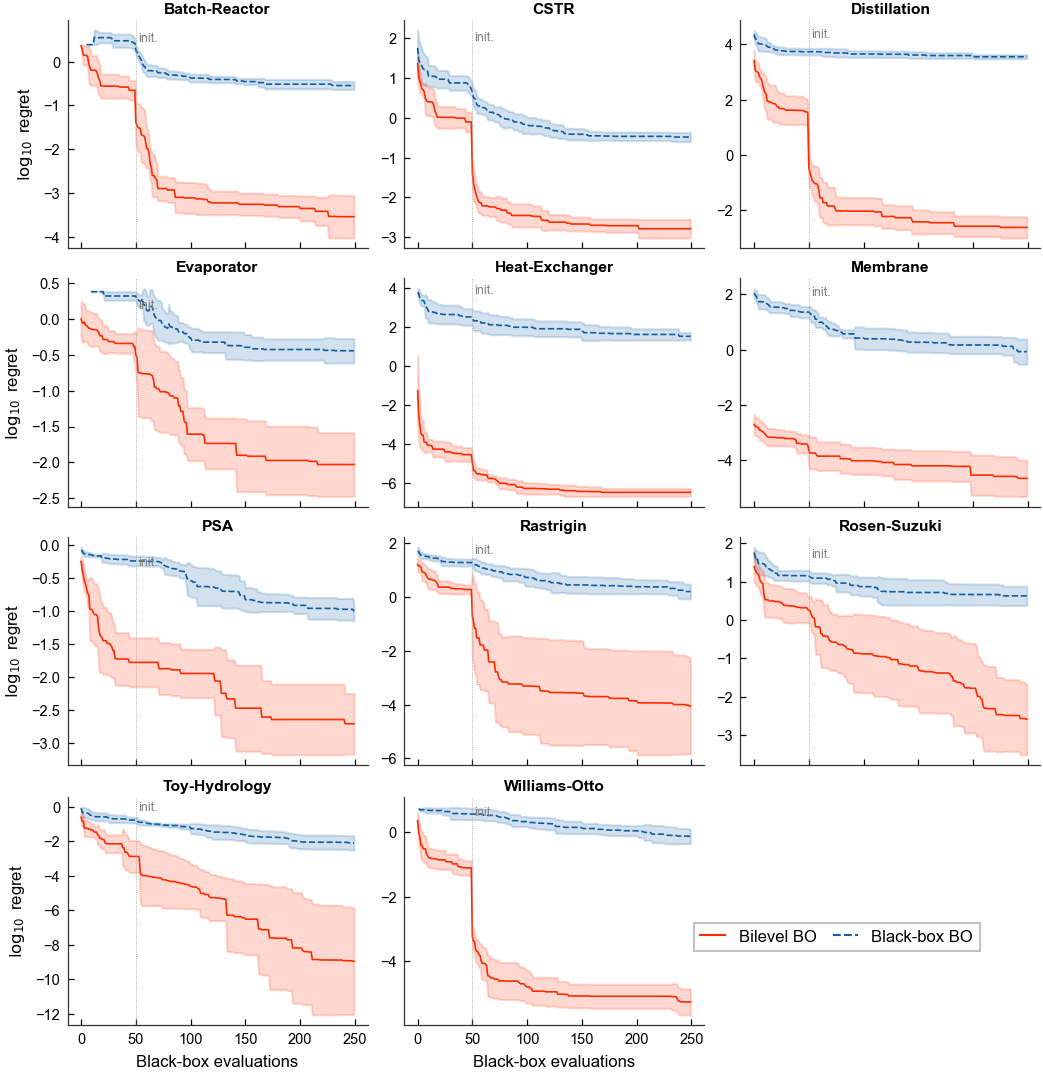

In [25]:
# -- Convergence Grid: all problems except SFR-1 and SFR-2 (4 rows x 3 cols) --
sfr_set = {'Small-Feasible-Region', 'Small-Feasible-Region-2'}
grid_probs = [p for p in problem_names if p not in sfr_set]
nrows, ncols = 4, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(COL2, 7.2))

res = xibest_data[50]['results']
n_init_here = xibest_data[50]['settings']['n_initial']

for idx, pname in enumerate(grid_probs):
    r, c = divmod(idx, ncols)
    ax = axes[r, c]
    prob = res[pname]

    plot_regret_curve(ax, prob['blackbox_bo_ei']['regrets'], C_BBBO, 'BB-BO', ls='--', lw=0.8)
    plot_regret_curve(ax, prob[BIBO_KEYS[0]]['regrets'], C_BIBO, 'Bi-BO', lw=0.8)
    ax.text(n_init_here + 2, ax.get_ylim()[1] - 0.3, 'init.', fontsize=6, color='0.5', va='top')

    ax.axvline(n_init_here, color='0.6', ls=':', lw=0.4)
    ax.set_title(pname, fontsize=7.5, pad=3)
    if r == nrows - 1:
        ax.set_xlabel('Black-box evaluations')
    else:
        ax.set_xticklabels([])
    if c == 0:
        ax.set_ylabel(r'$\log_{10}$ regret')

# Hide unused subplot(s)
for idx in range(len(grid_probs), nrows * ncols):
    r, c = divmod(idx, ncols)
    axes[r, c].axis('off')

legend_elements = [
    Line2D([0], [0], color=C_BIBO, ls='-', lw=1.0, label='Bilevel BO'),
    Line2D([0], [0], color=C_BBBO, ls='--', lw=1.0, label='Black-box BO'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=2,
           frameon=True, fancybox=False, edgecolor='0.7',
           bbox_to_anchor=(0.8, 0.15), fontsize=8)

fig.subplots_adjust(hspace=0.45, wspace=0.30)
save_fig(fig, 'convergence_grid')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved convergence_grid_4x3.eps/.pdf


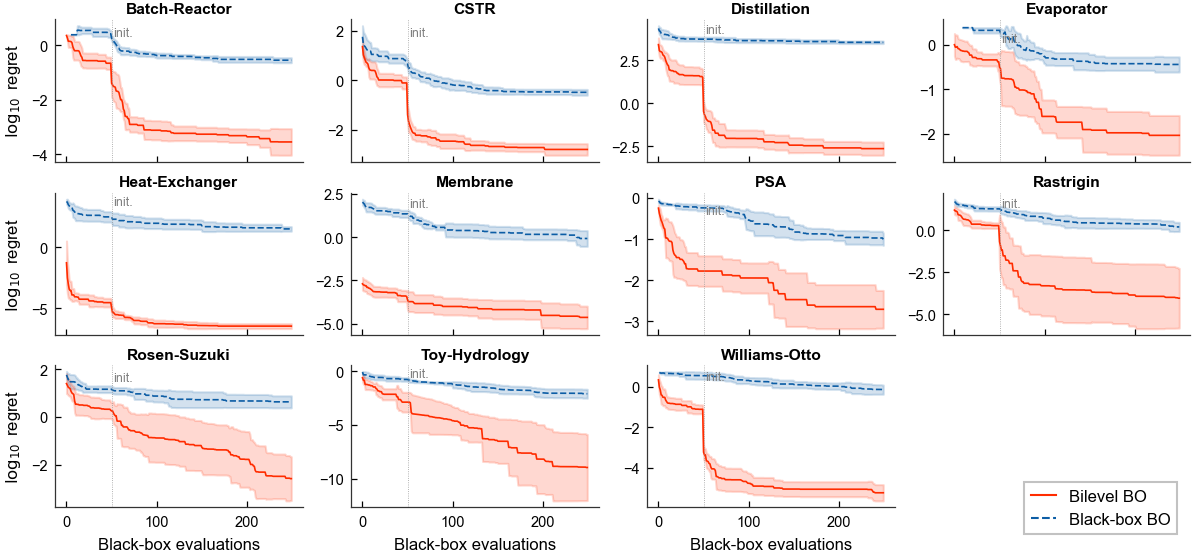

In [26]:
# -- Convergence Grid (rearranged): all problems except SFR-1/SFR-2, 4-wide x 3-high --
sfr_set = {'Small-Feasible-Region', 'Small-Feasible-Region-2'}
grid_probs = [p for p in problem_names if p not in sfr_set]
nrows, ncols = 3, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(8, 3.75))

res = xibest_data[50]['results']
n_init_here = xibest_data[50]['settings']['n_initial']

for idx, pname in enumerate(grid_probs):
    r, c = divmod(idx, ncols)
    ax = axes[r, c]
    prob = res[pname]

    plot_regret_curve(ax, prob['blackbox_bo_ei']['regrets'], C_BBBO, 'BB-BO', ls='--', lw=0.8)
    plot_regret_curve(ax, prob[BIBO_KEYS[0]]['regrets'], C_BIBO, 'Bi-BO', lw=0.8)
    ax.text(n_init_here + 2, ax.get_ylim()[1] - 0.3, 'init.', fontsize=6, color='0.5', va='top')

    ax.axvline(n_init_here, color='0.6', ls=':', lw=0.4)
    ax.set_title(pname, fontsize=7.5, pad=3)

    if r == nrows - 1:
        ax.set_xlabel('Black-box evaluations')
    else:
        ax.set_xticklabels([])

    if c == 0:
        ax.set_ylabel(r'$\log_{10}$ regret')

# Hide unused subplot(s)
for idx in range(len(grid_probs), nrows * ncols):
    r, c = divmod(idx, ncols)
    axes[r, c].axis('off')

legend_elements = [
    Line2D([0], [0], color=C_BIBO, ls='-', lw=1.0, label='Bilevel BO'),
    Line2D([0], [0], color=C_BBBO, ls='--', lw=1.0, label='Black-box BO'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=1,
           frameon=True, fancybox=False, edgecolor='0.7',
           bbox_to_anchor=(0.92, 0.15), fontsize=8)

fig.subplots_adjust(hspace=0.45, wspace=0.30)
save_fig(fig, 'convergence_grid_4x3')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved sfr_convergence.eps/.pdf


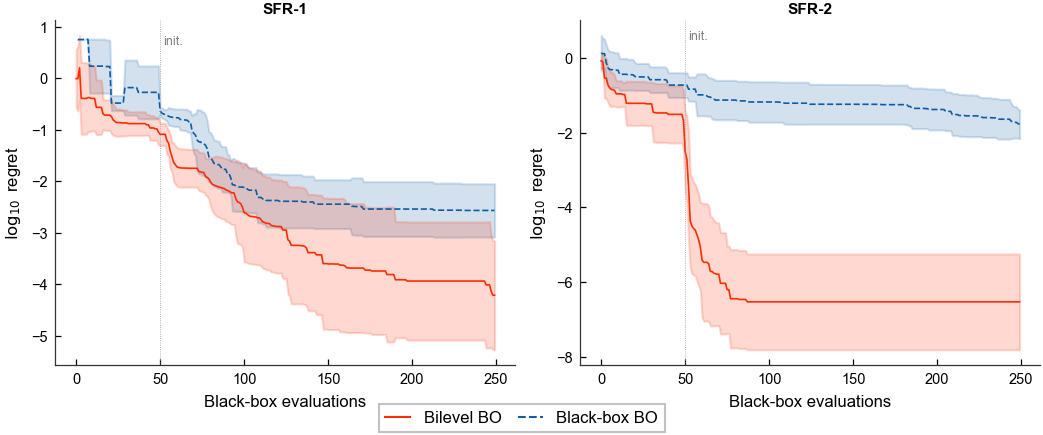

In [27]:
# -- SFR Convergence: Side-by-side convergence for Small-Feasible-Region problems --
sfr_names = ['Small-Feasible-Region', 'Small-Feasible-Region-2']
sfr_short = {'Small-Feasible-Region': 'SFR-1', 'Small-Feasible-Region-2': 'SFR-2'}

fig, axes = plt.subplots(1, 2, figsize=(COL2, 2.8))

res = xibest_data[50]['results']
n_init_here = xibest_data[50]['settings']['n_initial']

for ax, pname in zip(axes, sfr_names):
    prob = res[pname]
    plot_regret_curve(ax, prob['blackbox_bo_ei']['regrets'], C_BBBO, 'BB-BO', ls='--', lw=0.8)
    plot_regret_curve(ax, prob[BIBO_KEYS[0]]['regrets'], C_BIBO, 'Bi-BO', lw=0.8)

    ax.axvline(n_init_here, color='0.6', ls=':', lw=0.4)
    ax.text(n_init_here + 2, ax.get_ylim()[1] - 0.3, 'init.',
            fontsize=6, color='0.5', va='top')

    ax.set_xlabel('Black-box evaluations')
    ax.set_ylabel(r'$\log_{10}$ regret')
    ax.set_title(sfr_short[pname], fontsize=7.5, pad=3)

legend_elements = [
    Line2D([0], [0], color=C_BIBO, ls='-', lw=1.0, label='Bilevel BO'),
    Line2D([0], [0], color=C_BBBO, ls='--', lw=1.0, label='Black-box BO'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=2,
           frameon=True, fancybox=False, edgecolor='0.7',
           bbox_to_anchor=(0.5, 0.05), fontsize=8)

fig.subplots_adjust(wspace=0.30)
save_fig(fig, 'sfr_convergence')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved scatter_bb_vs_bi.eps/.pdf


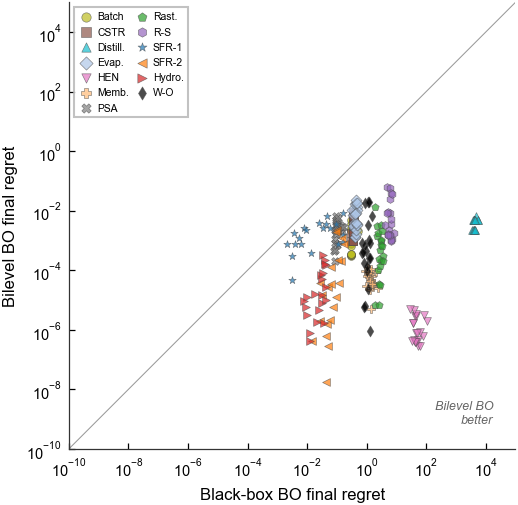

In [28]:
# -- Figure 4: BB-BO vs Bi-BO Scatter --
fig, ax = plt.subplots(figsize=(COL1, COL1))

scatter_pts = defaultdict(list)
for (ni, xi), d in all_data_merged.items():
    results = d['results']
    for pname in problem_names:
        bb_finals = [r[-1] for r in results[pname]['blackbox_bo_ei']['regrets']
                     if np.isfinite(r[-1])]
        bi_finals = [r[-1] for r in results[pname][BIBO_KEYS[0]]['regrets']
                     if np.isfinite(r[-1])]
        if bb_finals and bi_finals:
            bb_med = max(np.median(np.abs(bb_finals)), 1e-10)
            bi_med = max(np.median(np.abs(bi_finals)), 1e-10)
            scatter_pts[pname].append((bb_med, bi_med))

for pname in problem_names:
    pts = scatter_pts[pname]
    if not pts:
        continue
    bb_vals, bi_vals = zip(*pts)
    ax.scatter(bb_vals, bi_vals, s=14, alpha=0.7,
               color=PROB_COLORS[pname], marker=PROB_MARKERS[pname],
               label=PROB_META[pname]['short'],
               linewidths=0.3, edgecolors='0.3', zorder=3)

lims = [1e-10, 1e5]
ax.plot(lims, lims, 'k-', lw=0.5, alpha=0.4, zorder=1)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect('equal')
ax.set_xlabel('Black-box BO final regret')
ax.set_ylabel('Bilevel BO final regret')
ax.text(0.95, 0.05, 'Bilevel BO\nbetter', transform=ax.transAxes,
        ha='right', va='bottom', fontsize=6, fontstyle='italic', color='0.4')
ax.legend(fontsize=5, ncol=2, frameon=True, fancybox=False, edgecolor='0.7',
          loc='upper left', handletextpad=0.3, columnspacing=0.5, markerscale=1.2)

save_fig(fig, 'scatter_bb_vs_bi')
plt.show()

  Saved summary_table.eps/.pdf


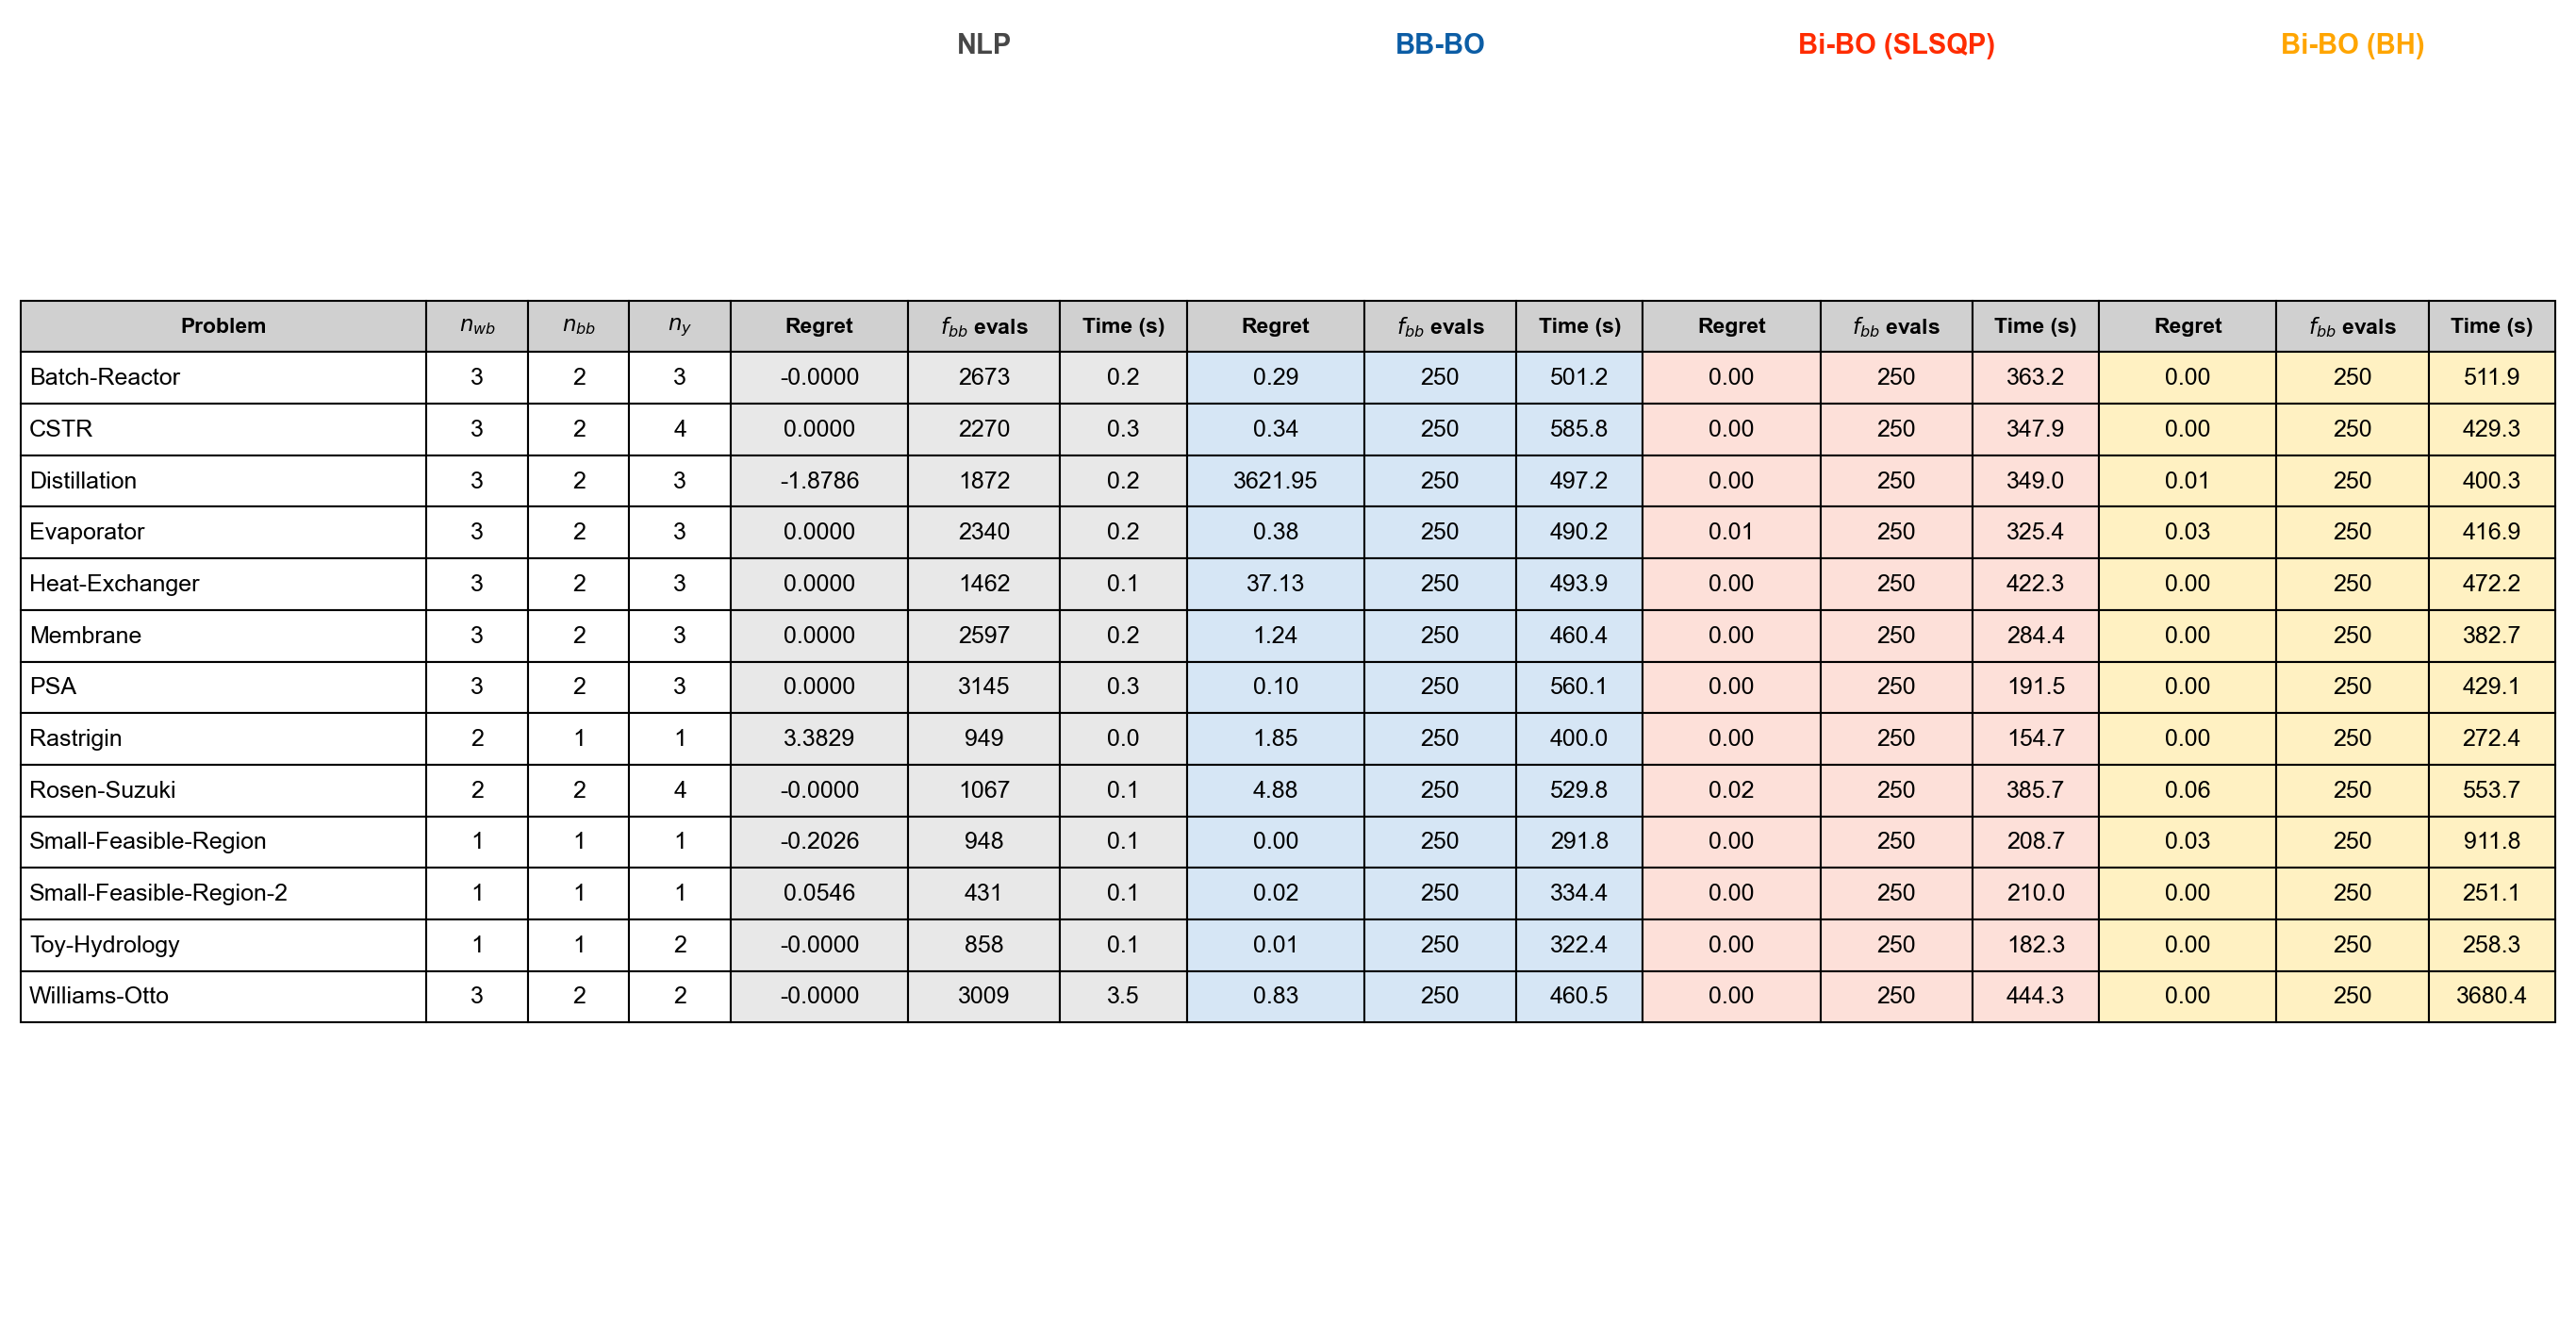

In [37]:
# -- Publication-style summary table figure ---------------------------------
# Columns: Problem | n_wb | n_bb | n_y | NLP {regret, fbb, t} |
#          BB-BO {regret, fbb, t} | (per Bi-BO variant) {regret, fbb, t}
PRES_STYLE = REPO_ROOT / 'presentation.mplstyle'

res_pres = xibest_data[50]['results']


def _tbl_stats(prob, solver_key, is_nlp=False):
    s = prob.get(solver_key)
    if s is None:
        return (np.nan, np.nan, np.nan)
    if is_nlp:
        regrets = np.array(s['final_regrets'])
    else:
        regrets = np.array([r[-1] for r in s['regrets']
                            if len(r) > 0 and np.isfinite(r[-1])])
    fbb = np.array(s['n_fbb_evals'])
    wt = np.array(s['wall_times'])
    return (np.mean(regrets) if len(regrets) else np.inf,
            np.mean(fbb) if len(fbb) else np.nan,
            np.mean(wt) if len(wt) else np.nan)


# Build columns dynamically: NLP, BB-BO, then one block per Bi-BO variant
solver_blocks = [
    ('NLP',   'multistart_slsqp', True,  C_NLP),
    ('BB-BO', 'blackbox_bo_ei',   False, C_BBBO),
]
for bi_label, bi_key, _ in BIBO_VARIANTS:
    solver_blocks.append((bi_label, bi_key, False, BIBO_COLORS[bi_key]))

table_rows = []
for pname in problem_names:
    prob = res_pres[pname]
    p = all_probs[pname]
    row = {'Problem': pname, 'n_wb': p.n_x_wb, 'n_bb': p.n_x_bb, 'n_y': p.n_y}
    for label, key, is_nlp, _ in solver_blocks:
        reg, fbb, wt = _tbl_stats(prob, key, is_nlp=is_nlp)
        row[f'{label} regret'] = reg
        row[f'{label} f_bb']   = fbb
        row[f'{label} time']   = wt
    table_rows.append(row)

# Column layout
fixed_cols = ['Problem', '$n_{wb}$', '$n_{bb}$', '$n_y$']
solver_sub_cols = ['Regret', '$f_{bb}$ evals', 'Time (s)']
col_labels = list(fixed_cols)
for label, _, _, _ in solver_blocks:
    col_labels.extend(solver_sub_cols)

with plt.style.context(str(PRES_STYLE)):
    n_solver_cols = 3 * len(solver_blocks)
    fig_width = max(18, 6 + 2.5 * len(solver_blocks))
    fig, ax = plt.subplots(figsize=(fig_width, max(9, 0.55 * len(table_rows) + 2)))
    ax.axis('off')

    cell_text = []
    for r in table_rows:
        row_cells = [r['Problem'], f"{r['n_wb']}", f"{r['n_bb']}", f"{r['n_y']}"]
        for label, _, is_nlp, _ in solver_blocks:
            reg = r[f'{label} regret']
            fbb = r[f'{label} f_bb']
            wt  = r[f'{label} time']
            reg_fmt = '4f' if is_nlp else '2f'
            row_cells.append('--' if not np.isfinite(reg) else f'{reg:.{reg_fmt}}')
            row_cells.append('--' if not np.isfinite(fbb) else f'{fbb:.0f}')
            row_cells.append('--' if not np.isfinite(wt)  else f'{wt:.1f}')
        cell_text.append(row_cells)

    table = ax.table(cellText=cell_text, colLabels=col_labels,
                     loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.0, 1.7)

    n_total_cols = 4 + n_solver_cols
    fixed_widths   = [0.16, 0.04, 0.04, 0.04]
    solver_widths  = [0.07, 0.06, 0.05]
    col_widths = fixed_widths + solver_widths * len(solver_blocks)
    # Normalise so widths sum to ~1.0
    s = sum(col_widths)
    col_widths = [w / s for w in col_widths]
    for row_idx in range(len(cell_text) + 1):
        for col_idx, cw in enumerate(col_widths):
            table[row_idx, col_idx].set_width(cw)

    # Header styling
    for j in range(n_total_cols):
        cell = table[0, j]
        cell.set_facecolor('#d0d0d0')
        cell.set_text_props(weight='bold', fontsize=11)

    # Block coloring
    block_palette = ['#e8e8e8', '#d6e6f5', '#fde0d9', '#fff1c2']
    for bi_idx, (label, _, _, _) in enumerate(solver_blocks):
        color = block_palette[bi_idx % len(block_palette)]
        col_start = 4 + 3 * bi_idx
        for c in range(col_start, col_start + 3):
            for row_idx in range(1, len(cell_text) + 1):
                table[row_idx, c].set_facecolor(color)

    # Left-align problem name
    for row_idx in range(1, len(cell_text) + 1):
        table[row_idx, 0].set_text_props(ha='left')
        table[row_idx, 0].PAD = 0.02

    # Group title labels above each solver block
    for bi_idx, (label, _, _, color) in enumerate(solver_blocks):
        center_col = 4 + 3 * bi_idx + 1
        x_frac = sum(col_widths[:center_col]) + col_widths[center_col] / 2
        ax.text(x_frac, 0.97, label, transform=ax.transAxes,
                ha='center', va='bottom', fontsize=14,
                fontweight='bold', color=color)

    save_fig(fig, 'summary_table')
    plt.show()

In [38]:
# -- LaTeX summary table with mean +/- std ----------------------------------
# Generates a publication-ready LaTeX table matching the paper's booktabs style.

res_latex = xibest_data[50]['results']


def _tbl_stats_with_std(prob, solver_key, is_nlp=False):
    """Return (mean_regret, std_regret, mean_fbb, std_fbb, mean_wt, std_wt)."""
    s = prob.get(solver_key)
    if s is None:
        return (np.nan, np.nan, np.nan, np.nan, np.nan, np.nan)
    if is_nlp:
        regrets = np.array(s['final_regrets'])
    else:
        regrets = np.array([r[-1] for r in s['regrets']
                            if len(r) > 0 and np.isfinite(r[-1])])
    fbb = np.array(s['n_fbb_evals'])
    wt = np.array(s['wall_times'])

    mr = np.mean(regrets) if len(regrets) else np.inf
    sr = np.std(regrets)  if len(regrets) else np.nan
    mf = np.mean(fbb)     if len(fbb) else np.nan
    sf = np.std(fbb)      if len(fbb) else np.nan
    mt = np.mean(wt)      if len(wt) else np.nan
    st = np.std(wt)       if len(wt) else np.nan
    return (mr, sr, mf, sf, mt, st)


def _fmt_regret(mean, std, is_nlp=False):
    """Format regret as mean +/- std with appropriate precision."""
    if not np.isfinite(mean):
        return '--'
    if is_nlp:
        if mean < 0.0001:
            return f'${mean:.1e}$'
        return f'${mean:.4f}$'
    # For BO methods: use scientific notation if very small or very large
    if mean == 0 and std == 0:
        return '$0$'
    if mean > 100:
        return f'${mean:.0f} \\pm {std:.0f}$'
    if mean > 1:
        return f'${mean:.2f} \\pm {std:.2f}$'
    if mean > 0.01:
        return f'${mean:.3f} \\pm {std:.3f}$'
    if mean > 0.0001:
        return f'${mean:.4f} \\pm {std:.4f}$'
    # Very small: scientific notation
    exp = int(np.floor(np.log10(max(mean, 1e-30))))
    scale = 10 ** exp
    m_s = mean / scale
    s_s = std / scale
    return f'$({m_s:.1f} \\pm {s_s:.1f})\\times 10^{{{exp}}}$'


def _fmt_fbb(mean, std):
    if not np.isfinite(mean):
        return '--'
    return f'${mean:.0f} \\pm {std:.0f}$'


def _fmt_time(mean, std):
    if not np.isfinite(mean):
        return '--'
    return f'${mean:.1f} \\pm {std:.1f}$'


# Solver blocks: (label, key, is_nlp)
latex_solver_blocks = [
    ('NLP',   'multistart_slsqp', True),
    ('BB-BO', 'blackbox_bo_ei',   False),
]
for bi_label, bi_key, _ in BIBO_VARIANTS:
    latex_solver_blocks.append((bi_label, bi_key, False))

# Determine number of solver groups for column spec
n_groups = len(latex_solver_blocks)

# Build column spec: l c c c | ccc | ccc | ...
col_spec = '@{}lccc'
for _ in latex_solver_blocks:
    col_spec += 'rrr'
col_spec += '@{}'

# Build header rows
header1_parts = [r'\multicolumn{4}{@{}c}{}']
for label, _, _ in latex_solver_blocks:
    header1_parts.append(
        r'\multicolumn{3}{c}{\textbf{' + label + '}}'
    )
header1 = ' & '.join(header1_parts) + r' \\'

# cmidrule for each solver group
cmidrules = ''
for i in range(n_groups):
    start = 5 + 3 * i
    end = start + 2
    cmidrules += f'\\cmidrule(lr){{{start}-{end}}} '

header2_parts = [
    r'\textbf{Problem}',
    r'$n_{\WB}$',
    r'$n_{\BB}$',
    r'$n_y$',
]
for _ in latex_solver_blocks:
    header2_parts.extend([r'Regret', r'$f_{\BB}$ evals', r'Time (s)'])
header2 = ' & '.join(header2_parts) + r' \\'

# Build rows
latex_rows = []
for i, pname in enumerate(problem_names):
    prob = res_latex[pname]
    p = all_probs[pname]

    cells = [pname, str(p.n_x_wb), str(p.n_x_bb), str(p.n_y)]
    for label, key, is_nlp in latex_solver_blocks:
        mr, sr, mf, sf, mt, st = _tbl_stats_with_std(prob, key, is_nlp=is_nlp)
        if is_nlp:
            cells.append(_fmt_regret(mr, sr, is_nlp=True))
            cells.append(_fmt_fbb(mf, sf))
            cells.append(_fmt_time(mt, st))
        else:
            cells.append(_fmt_regret(mr, sr))
            cells.append(_fmt_fbb(mf, sf))
            cells.append(_fmt_time(mt, st))

    row_str = ' & '.join(cells) + r' \\'
    # Add midrule after 5th problem (end of 2D group)
    if i == 4:
        row_str += '\n\\midrule'
    latex_rows.append(row_str)

# Assemble the full table
latex_table = r"""\begin{table}[htbp]
\centering
\caption{Summary statistics (mean $\pm$ std over 10 repetitions) for all 13 benchmark problems ($n_\text{init}=50$, best $\xi$). Regret $= |J_\text{best} - J^\star|$; $f_{\BB}$ evals counts black-box function evaluations; Time is wall-clock seconds.}
\label{tab:summary_stats}
\footnotesize
\setlength{\tabcolsep}{3pt}
\begin{tabular}{""" + col_spec + r"""}
\toprule
""" + header1 + '\n' + cmidrules + '\n' + header2 + '\n' + r"""\midrule
""" + '\n'.join(latex_rows) + r"""
\bottomrule
\end{tabular}
\end{table}"""

print(latex_table)

\begin{table}[htbp]
\centering
\caption{Summary statistics (mean $\pm$ std over 10 repetitions) for all 13 benchmark problems ($n_\text{init}=50$, best $\xi$). Regret $= |J_\text{best} - J^\star|$; $f_{\BB}$ evals counts black-box function evaluations; Time is wall-clock seconds.}
\label{tab:summary_stats}
\footnotesize
\setlength{\tabcolsep}{3pt}
\begin{tabular}{@{}lcccrrrrrrrrrrrr@{}}
\toprule
\multicolumn{4}{@{}c}{} & \multicolumn{3}{c}{\textbf{NLP}} & \multicolumn{3}{c}{\textbf{BB-BO}} & \multicolumn{3}{c}{\textbf{Bi-BO (SLSQP)}} & \multicolumn{3}{c}{\textbf{Bi-BO (BH)}} \\
\cmidrule(lr){5-7} \cmidrule(lr){8-10} \cmidrule(lr){11-13} \cmidrule(lr){14-16} 
\textbf{Problem} & $n_{\WB}$ & $n_{\BB}$ & $n_y$ & Regret & $f_{\BB}$ evals & Time (s) & Regret & $f_{\BB}$ evals & Time (s) & Regret & $f_{\BB}$ evals & Time (s) & Regret & $f_{\BB}$ evals & Time (s) \\
\midrule
Batch-Reactor & 3 & 2 & 3 & $-4.5e-07$ & $2673 \pm 61$ & $0.2 \pm 0.1$ & $0.289 \pm 0.058$ & $250 \pm 0$ & $501.2 \pm 16

In [39]:
# -- CSTR: Best estimates of process & catalyst variables ------
res_pres = xibest_data[50]['results']
cstr = res_pres['CSTR']
J_opt = cstr['J_optimal']
maximize = cstr['maximize']

var_names_wb = ['T (K)', 'P (bar)', r'$\tau$ (s)']
var_names_bb = [r'$E_b$ (eV)', r'$\Delta E_a$']
known_opt_wb = [647.25, 20.0, 5.0]
known_opt_bb = [-1.047, 0.2]

# Black-box BO
bb = cstr['blackbox_bo_ei']
n_reps_cstr = len(bb['X_history'])
bb_best_wb, bb_best_bb, bb_best_J = [], [], []
for rep in range(n_reps_cstr):
    Y = np.array(bb['Y_history'][rep])
    X = np.array(bb['X_history'][rep])
    idx = np.argmax(Y) if maximize else np.argmin(Y)
    bb_best_J.append(Y[idx])
    bb_best_wb.append(X[idx, :3])
    bb_best_bb.append(X[idx, 3:])
bb_best_wb = np.array(bb_best_wb)
bb_best_bb = np.array(bb_best_bb)
bb_best_J  = np.array(bb_best_J)

# Bilevel BO
bi = cstr[BIBO_KEYS[0]]
bi_best_wb, bi_best_bb, bi_best_J = [], [], []
for rep in range(n_reps_cstr):
    Y = np.array(bi['Y_history'][rep])
    X_bb = np.array(bi['X_bb_history'][rep])
    X_wb = bi['X_wb_history'][rep]
    idx = np.argmax(Y) if maximize else np.argmin(Y)
    bi_best_J.append(Y[idx])
    bi_best_bb.append(X_bb[idx])
    bi_best_wb.append(X_wb[idx])
bi_best_wb = np.array(bi_best_wb)
bi_best_bb = np.array(bi_best_bb)
bi_best_J  = np.array(bi_best_J)

header = (f'{"Variable":<16s} {"Known opt":>12s} {"BB-BO mean":>12s} '
          f'{"BB-BO std":>10s} {"Bi-BO mean":>12s} {"Bi-BO std":>10s}')
print(header)
print('-' * len(header))
for i, name in enumerate(var_names_wb):
    print(f'{name:<16s} {known_opt_wb[i]:>12.3f} '
          f'{bb_best_wb[:, i].mean():>12.3f} {bb_best_wb[:, i].std():>10.3f} '
          f'{bi_best_wb[:, i].mean():>12.3f} {bi_best_wb[:, i].std():>10.3f}')
for i, name in enumerate(var_names_bb):
    print(f'{name:<16s} {known_opt_bb[i]:>12.3f} '
          f'{bb_best_bb[:, i].mean():>12.3f} {bb_best_bb[:, i].std():>10.3f} '
          f'{bi_best_bb[:, i].mean():>12.3f} {bi_best_bb[:, i].std():>10.3f}')
print(f'{"J (% yield)":<16s} {J_opt:>12.3f} '
      f'{bb_best_J.mean():>12.3f} {bb_best_J.std():>10.3f} '
      f'{bi_best_J.mean():>12.3f} {bi_best_J.std():>10.3f}')

Variable            Known opt   BB-BO mean  BB-BO std   Bi-BO mean  Bi-BO std
-----------------------------------------------------------------------------
T (K)                 647.250      650.958      6.905      647.351      0.445
P (bar)                20.000       19.287      0.577       20.000      0.000
$\tau$ (s)              5.000        4.788      0.143        5.000      0.000
$E_b$ (eV)             -1.047       -1.051      0.041       -1.046      0.004
$\Delta E_a$            0.200        0.193      0.004        0.200      0.000
J (% yield)            92.324       91.986      0.091       92.322      0.001


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved fbb_evaluations.eps/.pdf


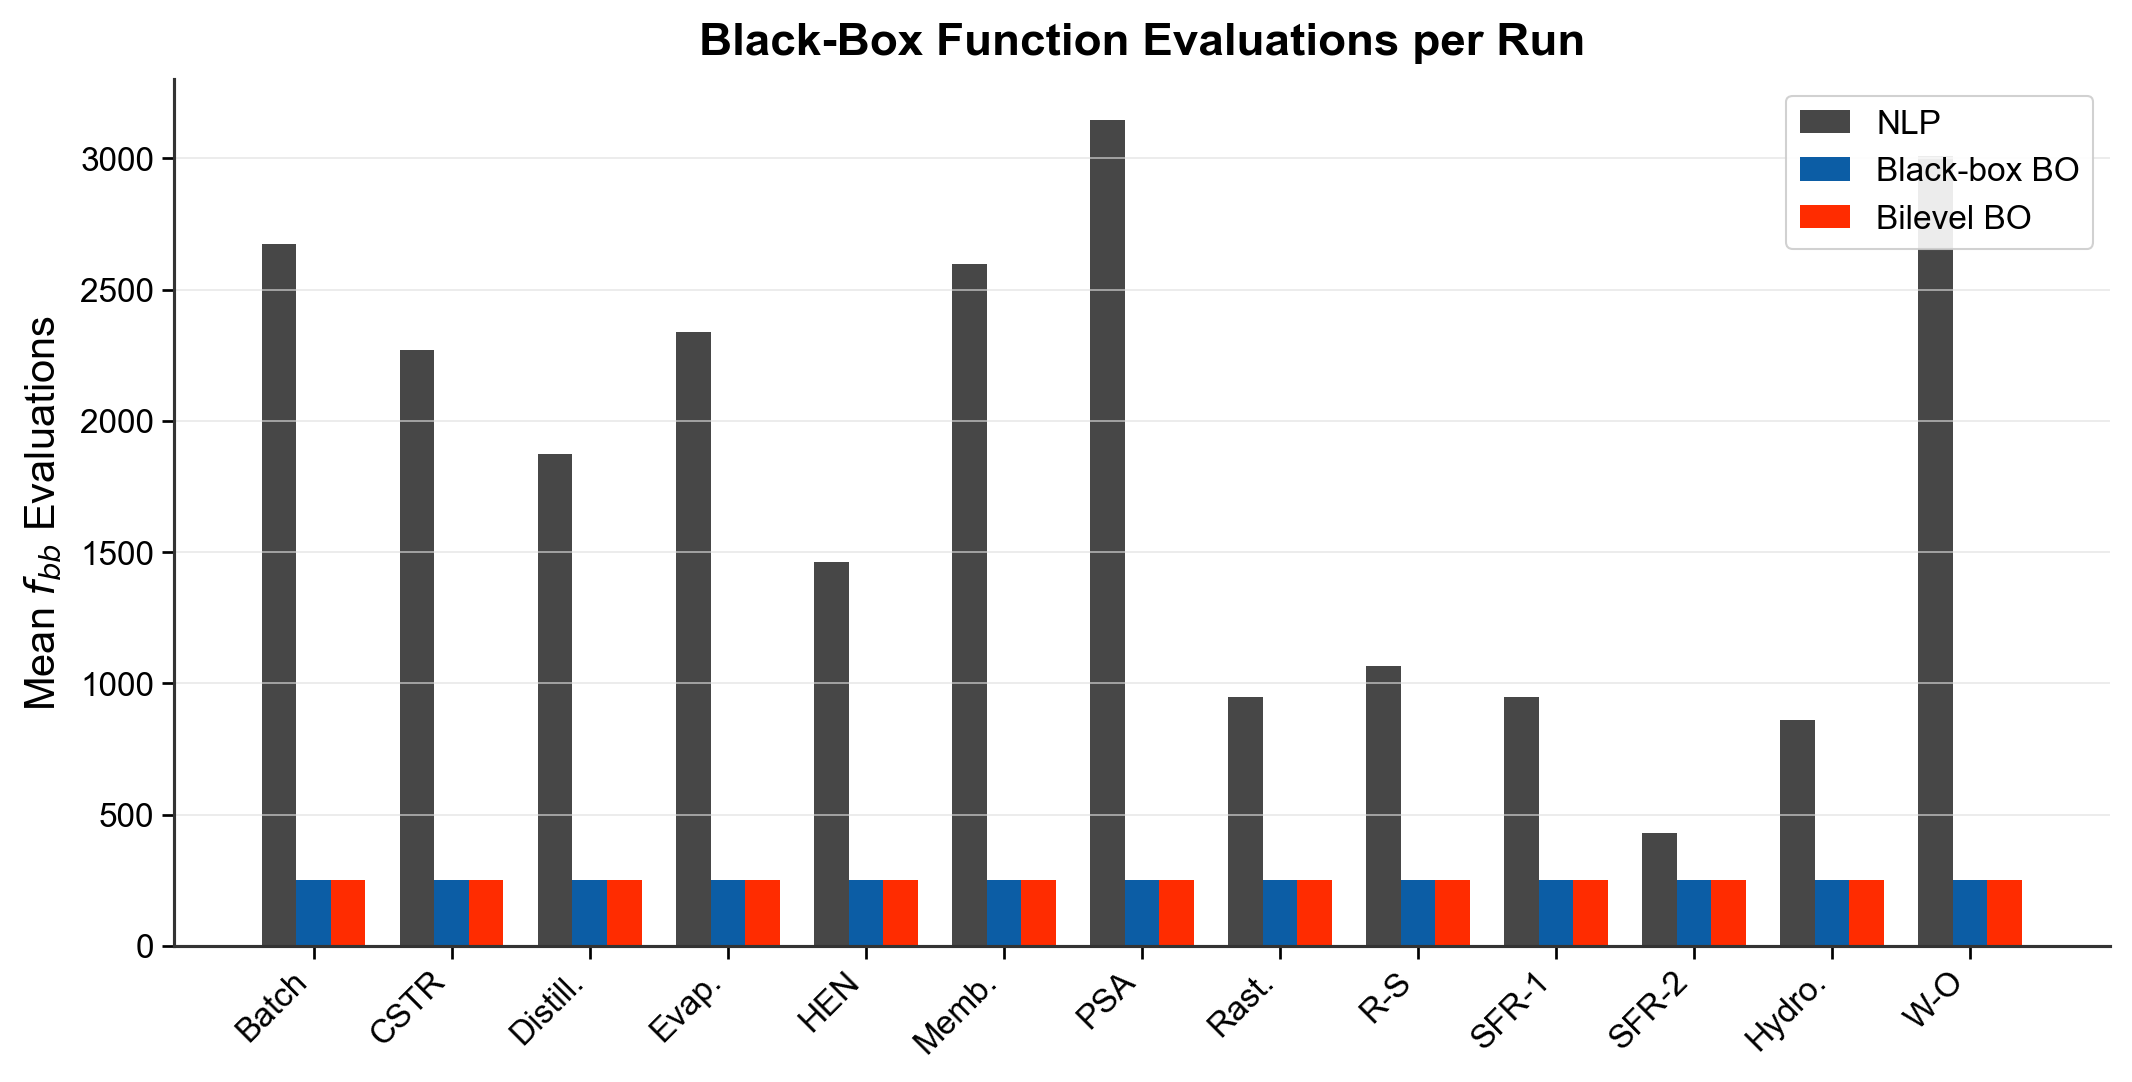

In [41]:
# -- Black-Box Function Evaluation Efficiency ---
res_pres = xibest_data[50]['results']

with plt.style.context(str(PRES_STYLE)):
    fig, ax = plt.subplots(figsize=(14, 7))
    x = np.arange(len(problem_names))
    w = 0.25

    nlp_fbb, bb_fbb, bi_fbb = [], [], []
    for pname in problem_names:
        prob = res_pres[pname]
        nlp_fbb.append(np.mean(prob['multistart_slsqp']['n_fbb_evals']))
        bb_fbb.append(np.mean(prob['blackbox_bo_ei']['n_fbb_evals']))
        bi_fbb.append(np.mean(prob[BIBO_KEYS[0]]['n_fbb_evals']))

    ax.bar(x - w, nlp_fbb, w, color=C_NLP, label='NLP')
    ax.bar(x,     bb_fbb,  w, color=C_BBBO, label='Black-box BO')
    ax.bar(x + w, bi_fbb,  w, color=C_BIBO, label='Bilevel BO')

    ax.set_ylabel('Mean $f_{bb}$ Evaluations')
    ax.set_xticks(x)
    ax.set_xticklabels([PROB_META[p]['short'] for p in problem_names],
                       rotation=45, ha='right')
    ax.legend()
    ax.set_title('Black-Box Function Evaluations per Run')

    save_fig(fig, 'fbb_evaluations')
    plt.show()

In [42]:
# -- SFR-1: Setup, background grids, and static preview 
if ANIMATE:
    from functions import create_small_feasible_region
    from solvers import solve_blackbox_bo, solve_bilevel_bo

    prob_sfr1 = create_small_feasible_region()
    N_INIT_SFR, N_ITER_SFR, SEED_SFR = 50, 200, 0

    res_bb_sfr1 = solve_blackbox_bo(
        prob_sfr1, n_iterations=N_ITER_SFR, n_initial=N_INIT_SFR,
        seed=SEED_SFR, verbose=False, return_history=True, xi=0.01)
    res_bi_sfr1 = solve_bilevel_bo(
        prob_sfr1, n_iterations=N_ITER_SFR, n_initial=N_INIT_SFR,
        seed=SEED_SFR, verbose=False, return_history=True, xi=0.01)

    bb1_xwb = res_bb_sfr1['X_history'][:, 0]
    bb1_xbb = res_bb_sfr1['X_history'][:, 1]
    bi1_xbb = np.asarray(res_bi_sfr1['X_bb_history']).ravel()
    bi1_xwb = np.asarray([xw[0] for xw in res_bi_sfr1['X_wb_history']])
    n_total1 = N_INIT_SFR + N_ITER_SFR
    print(f'SFR-1 -- BB-BO: {len(bb1_xwb)} pts,  Bi-BO: {len(bi1_xwb)} pts')

    # Background grids
    grid = 300
    xw = np.linspace(0, 6, grid)
    xb = np.linspace(0, 6, grid)
    XW, XB = np.meshgrid(xw, xb)
    J_grid = np.sin(XW) + XB
    G_grid = np.sin(XW) * np.sin(XB) + 0.95
    xwb_star = prob_sfr1.x_wb_optimal[0]
    xbb_star = prob_sfr1.x_bb_optimal[0]

    def draw_bg_sfr1(fig, ax, title):
        from matplotlib.patches import Rectangle
        levels_J = np.linspace(J_grid.min(), J_grid.max(), 30)
        cf = ax.contourf(XW, XB, J_grid, levels=levels_J, cmap='viridis_r')
        ax.contour(XW, XB, J_grid, levels=levels_J, colors='black', linewidths=0.4, alpha=0.35)
        cbar = fig.colorbar(cf, ax=ax, shrink=0.75, pad=0.03)
        cbar.set_label('$J(x^{WB}, x^{BB})$', fontsize=12)
        ax.contourf(XW, XB, G_grid, levels=[0, 1e3], colors=['white'], alpha=0.7)
        ax.contour(XW, XB, G_grid, levels=[0], colors=['black'], linewidths=2.0)
        ax.contourf(XW, XB, G_grid, levels=[-1e3, 0], colors=['none'], hatches=['oo'], alpha=0)
        ax.add_patch(Rectangle((0, 0), 0, 0, facecolor='none', edgecolor='black', hatch='oo', label='Feasible'))
        ax.plot(xwb_star, xbb_star, marker='*', color='gold', markersize=18,
                markeredgecolor='black', markeredgewidth=1.0, zorder=10, label='Optimum')
        ax.set_xlim(0, 6); ax.set_ylim(0, 6)
        ax.set_xlabel('$x^{WB}$'); ax.set_ylabel('$x^{BB}$')
        ax.set_title(title); ax.set_aspect('equal')

    # Static preview
    with plt.style.context(str(PRES_STYLE)):
        fig, (ax_bb, ax_bi) = plt.subplots(1, 2, figsize=(14, 6.5), constrained_layout=True)
        draw_bg_sfr1(fig, ax_bb, 'Black-box BO')
        draw_bg_sfr1(fig, ax_bi, 'Bilevel BO')
        ax_bb.scatter(bb1_xwb[:N_INIT_SFR], bb1_xbb[:N_INIT_SFR], s=60, facecolors='none',
                    edgecolors=C_BBBO, linewidths=1.5, zorder=5, label='initial')
        ax_bi.scatter(bi1_xwb[:N_INIT_SFR], bi1_xbb[:N_INIT_SFR], s=60, facecolors='none',
                    edgecolors=C_BIBO, linewidths=1.5, zorder=5, label='initial')
        ax_bb.scatter(bb1_xwb[N_INIT_SFR:], bb1_xbb[N_INIT_SFR:], s=60, c=C_BBBO,
                    edgecolors='white', linewidths=0.5, zorder=6, label='BO query')
        ax_bi.scatter(bi1_xwb[N_INIT_SFR:], bi1_xbb[N_INIT_SFR:], s=60, c=C_BIBO,
                    edgecolors='white', linewidths=0.5, zorder=6, label='BO query')
        ax_bb.legend(loc='upper left', fontsize=10)
        ax_bi.legend(loc='upper left', fontsize=10)
        fig.suptitle(f'SFR-1: Final state ({N_INIT_SFR} initial + {N_ITER_SFR} BO iterations)', fontsize=16)
        save_fig(fig, 'search_sfr1_static')
        plt.show()

In [43]:
# -- SFR-1: Build animation 
if ANIMATE:
    from matplotlib.animation import FuncAnimation, FFMpegWriter

    with plt.style.context(str(PRES_STYLE)):
        fig, (ax_bb, ax_bi) = plt.subplots(1, 2, figsize=(14, 6.5), constrained_layout=True)
        draw_bg_sfr1(fig, ax_bb, 'Black-box BO')
        draw_bg_sfr1(fig, ax_bi, 'Bilevel BO')

        scat_bb_init = ax_bb.scatter([], [], s=60, facecolors='none', edgecolors=C_BBBO,
                                    linewidths=1.5, zorder=5, label='initial')
        scat_bb_bo   = ax_bb.scatter([], [], s=60, c=C_BBBO, edgecolors='white',
                                    linewidths=0.5, zorder=6, label='BO query')
        scat_bi_init = ax_bi.scatter([], [], s=60, facecolors='none', edgecolors=C_BIBO,
                                    linewidths=1.5, zorder=5, label='initial')
        scat_bi_bo   = ax_bi.scatter([], [], s=60, c=C_BIBO, edgecolors='white',
                                    linewidths=0.5, zorder=6, label='BO query')
        high_bb, = ax_bb.plot([], [], 'o', ms=12, mec=C_BBBO, mfc='none', mew=2.5, zorder=7)
        high_bi, = ax_bi.plot([], [], 'o', ms=12, mec=C_BIBO, mfc='none', mew=2.5, zorder=7)
        iter_text = fig.suptitle('', fontsize=16)
        ax_bb.legend(loc='upper left', fontsize=10)
        ax_bi.legend(loc='upper left', fontsize=10)

        def init1():
            return scat_bb_init, scat_bb_bo, scat_bi_init, scat_bi_bo, high_bb, high_bi, iter_text

        def update1(frame):
            k = frame + 1
            if k <= N_INIT_SFR:
                scat_bb_init.set_offsets(np.c_[bb1_xwb[:k], bb1_xbb[:k]])
                scat_bb_bo.set_offsets(np.empty((0, 2)))
                scat_bi_init.set_offsets(np.c_[bi1_xwb[:k], bi1_xbb[:k]])
                scat_bi_bo.set_offsets(np.empty((0, 2)))
                iter_text.set_text(f'Initial sample {k}/{N_INIT_SFR}')
            else:
                scat_bb_init.set_offsets(np.c_[bb1_xwb[:N_INIT_SFR], bb1_xbb[:N_INIT_SFR]])
                scat_bb_bo.set_offsets(np.c_[bb1_xwb[N_INIT_SFR:k], bb1_xbb[N_INIT_SFR:k]])
                scat_bi_init.set_offsets(np.c_[bi1_xwb[:N_INIT_SFR], bi1_xbb[:N_INIT_SFR]])
                scat_bi_bo.set_offsets(np.c_[bi1_xwb[N_INIT_SFR:k], bi1_xbb[N_INIT_SFR:k]])
                iter_text.set_text(f'BO iteration {k - N_INIT_SFR}/{N_ITER_SFR}')
            high_bb.set_data([bb1_xwb[k-1]], [bb1_xbb[k-1]])
            high_bi.set_data([bi1_xwb[k-1]], [bi1_xbb[k-1]])
            return scat_bb_init, scat_bb_bo, scat_bi_init, scat_bi_bo, high_bb, high_bi, iter_text

        anim = FuncAnimation(fig, update1, init_func=init1, frames=n_total1, interval=200, blit=False)
        anim.save(REPORT_FIGS_DIR / 'search_animation_sfr1.mp4', writer=FFMpegWriter(fps=5))
        print('Saved search_animation_sfr1.mp4')
        plt.show()

In [44]:
if ANIMATE:
    # -- SFR-2: Setup, background grids, and static preview 
    from functions import create_small_feasible_region2
    from solvers import solve_blackbox_bo as _solve_bb2, solve_bilevel_bo as _solve_bi2

    prob_sfr2 = create_small_feasible_region2()

    res_bb2 = _solve_bb2(prob_sfr2, n_iterations=N_ITER_SFR, n_initial=N_INIT_SFR,
                        seed=SEED_SFR, verbose=False, return_history=True, xi=0.01)
    res_bi2 = _solve_bi2(prob_sfr2, n_iterations=N_ITER_SFR, n_initial=N_INIT_SFR,
                        seed=SEED_SFR, verbose=False, return_history=True, xi=0.01)

    bb2_xwb = res_bb2['X_history'][:, 0]
    bb2_xbb = res_bb2['X_history'][:, 1]
    bi2_xbb = np.asarray(res_bi2['X_bb_history']).ravel()
    bi2_xwb = np.asarray([xw[0] for xw in res_bi2['X_wb_history']])
    n_total2 = N_INIT_SFR + N_ITER_SFR
    print(f'SFR-2 -- BB-BO: {len(bb2_xwb)} pts,  Bi-BO: {len(bi2_xwb)} pts')

    # Background grids
    grid2 = 300
    xw2 = np.linspace(0, 6, grid2)
    xb2 = np.linspace(0, 6, grid2)
    XW2, XB2 = np.meshgrid(xw2, xb2)
    Y2_grid = (XB2 - 5.5) / 2 * np.exp(XB2 / 2)
    J2_grid = np.cos(2 * XW2) * np.cos(Y2_grid) + np.sin(XW2)
    G2_grid = np.cos(XW2) * np.cos(Y2_grid) - np.sin(XW2) * np.sin(Y2_grid) - 0.5
    xwb2_star = prob_sfr2.x_wb_optimal[0]
    xbb2_star = prob_sfr2.x_bb_optimal[0]

    def draw_bg_sfr2(fig, ax, title):
        from matplotlib.patches import Rectangle
        levels_J = np.linspace(J2_grid.min(), J2_grid.max(), 30)
        cf = ax.contourf(XW2, XB2, J2_grid, levels=levels_J, cmap='viridis_r')
        ax.contour(XW2, XB2, J2_grid, levels=levels_J, colors='black', linewidths=0.4, alpha=0.35)
        cbar = fig.colorbar(cf, ax=ax, shrink=0.75, pad=0.03)
        cbar.set_label('$J(x^{WB}, x^{BB})$', fontsize=12)
        ax.contourf(XW2, XB2, G2_grid, levels=[0, 1e3], colors=['white'], alpha=0.7)
        ax.contour(XW2, XB2, G2_grid, levels=[0], colors=['black'], linewidths=2.0)
        ax.contourf(XW2, XB2, G2_grid, levels=[-1e3, 0], colors=['none'], hatches=['oo'], alpha=0)
        ax.add_patch(Rectangle((0, 0), 0, 0, facecolor='none', edgecolor='black', hatch='oo', label='Feasible'))
        ax.plot(xwb2_star, xbb2_star, marker='*', color='gold', markersize=18,
                markeredgecolor='black', markeredgewidth=1.0, zorder=10, label='Optimum')
        ax.set_xlim(0, 6); ax.set_ylim(0, 6)
        ax.set_xlabel('$x^{WB}$'); ax.set_ylabel('$x^{BB}$')
        ax.set_title(title); ax.set_aspect('equal')

    # Static preview
    with plt.style.context(str(PRES_STYLE)):
        fig, (ax_bb, ax_bi) = plt.subplots(1, 2, figsize=(14, 6.5), constrained_layout=True)
        draw_bg_sfr2(fig, ax_bb, 'Black-box BO')
        draw_bg_sfr2(fig, ax_bi, 'Bilevel BO')
        ax_bb.scatter(bb2_xwb[:N_INIT_SFR], bb2_xbb[:N_INIT_SFR], s=60, facecolors='none',
                    edgecolors=C_BBBO, linewidths=1.5, zorder=5, label='initial')
        ax_bi.scatter(bi2_xwb[:N_INIT_SFR], bi2_xbb[:N_INIT_SFR], s=60, facecolors='none',
                    edgecolors=C_BIBO, linewidths=1.5, zorder=5, label='initial')
        ax_bb.scatter(bb2_xwb[N_INIT_SFR:], bb2_xbb[N_INIT_SFR:], s=60, c=C_BBBO,
                    edgecolors='white', linewidths=0.5, zorder=6, label='BO query')
        ax_bi.scatter(bi2_xwb[N_INIT_SFR:], bi2_xbb[N_INIT_SFR:], s=60, c=C_BIBO,
                    edgecolors='white', linewidths=0.5, zorder=6, label='BO query')
        ax_bb.legend(loc='upper left', fontsize=10)
        ax_bi.legend(loc='upper left', fontsize=10)
        fig.suptitle(f'SFR-2: Final state ({N_INIT_SFR} initial + {N_ITER_SFR} BO iterations)', fontsize=16)
        save_fig(fig, 'search_sfr2_static')
        plt.show()

In [45]:
if ANIMATE:
    # -- SFR-2: Build animation 
    from matplotlib.animation import FuncAnimation, FFMpegWriter

    with plt.style.context(str(PRES_STYLE)):
        fig, (ax_bb, ax_bi) = plt.subplots(1, 2, figsize=(14, 6.5), constrained_layout=True)
        draw_bg_sfr2(fig, ax_bb, 'Black-box BO')
        draw_bg_sfr2(fig, ax_bi, 'Bilevel BO')

        scat_bb2_init = ax_bb.scatter([], [], s=60, facecolors='none', edgecolors=C_BBBO,
                                    linewidths=1.5, zorder=5, label='initial')
        scat_bb2_bo   = ax_bb.scatter([], [], s=60, c=C_BBBO, edgecolors='white',
                                    linewidths=0.5, zorder=6, label='BO query')
        scat_bi2_init = ax_bi.scatter([], [], s=60, facecolors='none', edgecolors=C_BIBO,
                                    linewidths=1.5, zorder=5, label='initial')
        scat_bi2_bo   = ax_bi.scatter([], [], s=60, c=C_BIBO, edgecolors='white',
                                    linewidths=0.5, zorder=6, label='BO query')
        high_bb2, = ax_bb.plot([], [], 'o', ms=12, mec=C_BBBO, mfc='none', mew=2.5, zorder=7)
        high_bi2, = ax_bi.plot([], [], 'o', ms=12, mec=C_BIBO, mfc='none', mew=2.5, zorder=7)
        iter_text2 = fig.suptitle('', fontsize=16)
        ax_bb.legend(loc='upper left', fontsize=10)
        ax_bi.legend(loc='upper left', fontsize=10)

        def init2():
            return scat_bb2_init, scat_bb2_bo, scat_bi2_init, scat_bi2_bo, high_bb2, high_bi2, iter_text2

        def update2(frame):
            k = frame + 1
            if k <= N_INIT_SFR:
                scat_bb2_init.set_offsets(np.c_[bb2_xwb[:k], bb2_xbb[:k]])
                scat_bb2_bo.set_offsets(np.empty((0, 2)))
                scat_bi2_init.set_offsets(np.c_[bi2_xwb[:k], bi2_xbb[:k]])
                scat_bi2_bo.set_offsets(np.empty((0, 2)))
                iter_text2.set_text(f'Initial sample {k}/{N_INIT_SFR}')
            else:
                scat_bb2_init.set_offsets(np.c_[bb2_xwb[:N_INIT_SFR], bb2_xbb[:N_INIT_SFR]])
                scat_bb2_bo.set_offsets(np.c_[bb2_xwb[N_INIT_SFR:k], bb2_xbb[N_INIT_SFR:k]])
                scat_bi2_init.set_offsets(np.c_[bi2_xwb[:N_INIT_SFR], bi2_xbb[:N_INIT_SFR]])
                scat_bi2_bo.set_offsets(np.c_[bi2_xwb[N_INIT_SFR:k], bi2_xbb[N_INIT_SFR:k]])
                iter_text2.set_text(f'BO iteration {k - N_INIT_SFR}/{N_ITER_SFR}')
            high_bb2.set_data([bb2_xwb[k-1]], [bb2_xbb[k-1]])
            high_bi2.set_data([bi2_xwb[k-1]], [bi2_xbb[k-1]])
            return scat_bb2_init, scat_bb2_bo, scat_bi2_init, scat_bi2_bo, high_bb2, high_bi2, iter_text2

        anim2 = FuncAnimation(fig, update2, init_func=init2, frames=n_total2, interval=200, blit=False)
        anim2.save(REPORT_FIGS_DIR / 'search_animation_sfr2.mp4', writer=FFMpegWriter(fps=5))
        print('Saved search_animation_sfr2.mp4')
        plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved feasibility_rates.eps/.pdf


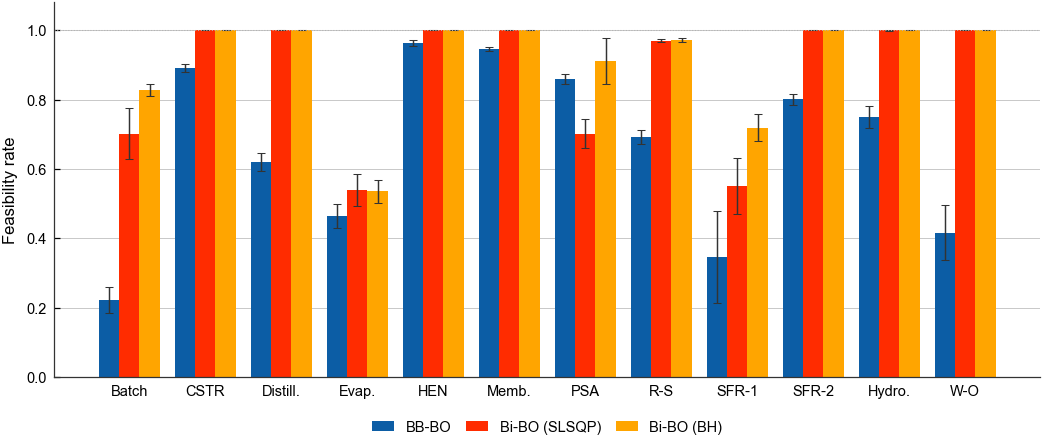

Problem                               BB-BO      Bi-BO (SLSQP)         Bi-BO (BH)
Batch                      22.2% +/-  3.8%   70.2% +/-  7.3%   82.7% +/-  1.8%
CSTR                       89.2% +/-  1.1%  100.0% +/-  0.0%  100.0% +/-  0.0%
Distill.                   62.0% +/-  2.5%  100.0% +/-  0.0%  100.0% +/-  0.0%
Evap.                      46.4% +/-  3.4%   53.8% +/-  4.6%   53.6% +/-  3.3%
HEN                        96.3% +/-  0.8%  100.0% +/-  0.0%  100.0% +/-  0.0%
Memb.                      94.7% +/-  0.6%  100.0% +/-  0.0%  100.0% +/-  0.0%
PSA                        86.0% +/-  1.4%   70.2% +/-  4.2%   91.1% +/-  6.7%
R-S                        69.2% +/-  1.9%   97.0% +/-  0.5%   97.2% +/-  0.6%
SFR-1                      34.6% +/- 13.1%   55.0% +/-  8.1%   71.9% +/-  3.9%
SFR-2                      80.0% +/-  1.5%  100.0% +/-  0.0%  100.0% +/-  0.0%
Hydro.                     74.9% +/-  3.2%  100.0% +/-  0.1%  100.0% +/-  0.0%
W-O                        41.6% +/-  7.9%  100.0

In [53]:
# -- Feasibility rate bar chart with error bars ---------------------------
# Fraction of the 250 evaluations that land in the feasible region, per
# constrained problem, averaged across repetitions. Error bars show +/-1
# std across the 10 repetitions. Feasibility: max(g(x_wb, y)) <= 1e-6.

FEAS_TOL = 1e-6


def _bb_feas_rate(prob_obj, X_hist):
    """Fraction of rows of X_hist (combined [x_wb, x_bb]) that are feasible."""
    n_feas = 0
    for x in X_hist:
        _, g = prob_obj.evaluate_blackbox_with_constraints(x, count_eval=False)
        if g.size == 0 or np.max(g) <= FEAS_TOL:
            n_feas += 1
    return n_feas / len(X_hist)


def _bi_feas_rate(prob_obj, X_bb_hist, X_wb_hist):
    """Fraction of Bi-BO evaluations whose inner solution is feasible."""
    n_feas = 0
    for x_bb, x_wb in zip(X_bb_hist, X_wb_hist):
        y = prob_obj.fbb(x_bb)
        g = prob_obj.g(x_wb, y) if prob_obj.g is not None else np.array([])
        if g.size == 0 or np.max(g) <= FEAS_TOL:
            n_feas += 1
    return n_feas / len(X_bb_hist)


res_feas = xibest_data[50]['results']
constrained_probs = [p for p in problem_names if PROB_META[p]['n_g'] > 0]

feas_data = {'BB-BO': []}
for lbl, _, _ in BIBO_VARIANTS:
    feas_data[lbl] = []

for pname in constrained_probs:
    prob_obj = all_probs[pname]
    prob_res = res_feas[pname]

    bb_hist = prob_res['blackbox_bo_ei']['X_history']
    feas_data['BB-BO'].append(
        [_bb_feas_rate(prob_obj, Xh) for Xh in bb_hist]
    )

    for lbl, key, _ in BIBO_VARIANTS:
        if key not in prob_res:
            feas_data[lbl].append([np.nan])
            continue
        xbb = prob_res[key]['X_bb_history']
        xwb = prob_res[key]['X_wb_history']
        feas_data[lbl].append(
            [_bi_feas_rate(prob_obj, xbb[r], xwb[r]) for r in range(len(xbb))]
        )

# -- Plot --
methods = list(feas_data.keys())
n_m = len(methods)
x = np.arange(len(constrained_probs))
w = 0.8 / n_m

bar_colors = {'BB-BO': C_BBBO}
for lbl, _, col in BIBO_VARIANTS:
    bar_colors[lbl] = col

fig, ax = plt.subplots(figsize=(COL2, 3.0))
for i, m in enumerate(methods):
    means = np.array([np.mean(r) for r in feas_data[m]])
    stds  = np.array([np.std(r)  for r in feas_data[m]])
    offset = (i - (n_m - 1) / 2) * w
    ax.bar(x + offset, means, w, yerr=stds,
           color=bar_colors[m], label=m,
           error_kw={'elinewidth': 0.7, 'capsize': 2, 'ecolor': '0.2'})

ax.set_ylabel('Feasibility rate')
ax.set_xticks(x)
ax.set_xticklabels([PROB_META[p]['short'] for p in constrained_probs],
                #    rotation=30, ha='right')
)
ax.set_ylim(0, 1.08)
ax.axhline(1.0, color='0.7', lw=0.5, ls=':')
ax.legend(loc='upper center', frameon=False, ncol=n_m, bbox_to_anchor=(0.5, -0.08))
ax.set_axisbelow(True)
ax.yaxis.grid(True, color='gray', lw=0.4)

save_fig(fig, 'feasibility_rates')
plt.show()

# -- Print summary table --
print(f'{"Problem":<24s}' + ''.join(f' {m:>18s}' for m in methods))
for i, pname in enumerate(constrained_probs):
    row = f'{PROB_META[pname]["short"]:<24s}'
    for m in methods:
        mu = np.mean(feas_data[m][i])
        sd = np.std(feas_data[m][i])
        row += f'  {mu:6.1%} +/- {sd:5.1%}'
    print(row)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved sample_crossover.eps/.pdf


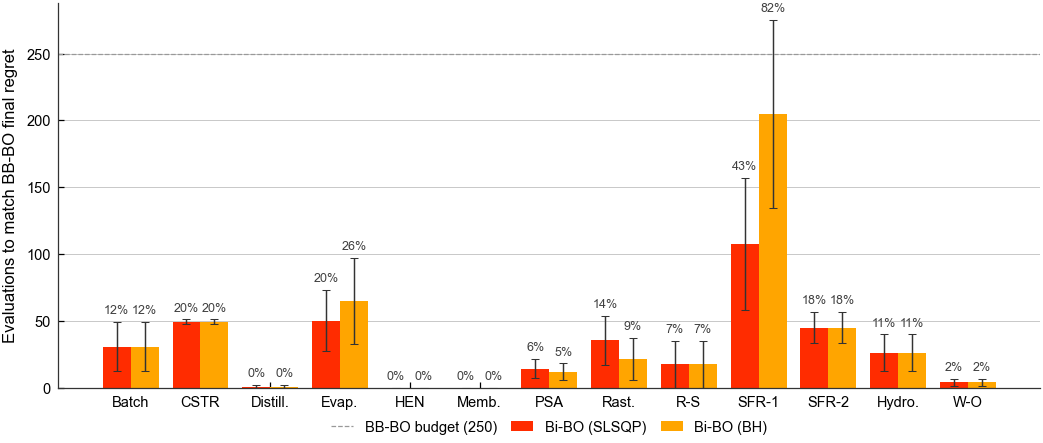

Problem        BB-BO target        Bi-BO (SLSQP) k           Bi-BO (BH) k
Batch                0.2894    30.7 +/- 18.5 (12%)    30.7 +/- 18.5 (12%)
CSTR                 0.3381    49.4 +/-  1.8 (20%)    49.4 +/-  1.8 (20%)
Distill.               3622     0.8 +/-  1.2 ( 0%)     0.8 +/-  1.2 ( 0%)
Evap.                0.3841    50.2 +/- 22.9 (20%)    64.9 +/- 32.1 (26%)
HEN                   37.13     0.0 +/-  0.0 ( 0%)     0.0 +/-  0.0 ( 0%)
Memb.                 1.241     0.0 +/-  0.0 ( 0%)     0.0 +/-  0.0 ( 0%)
PSA                  0.1044    14.4 +/-  7.3 ( 6%)    12.1 +/-  6.1 ( 5%)
Rast.                 1.846    35.6 +/- 18.4 (14%)    21.4 +/- 15.9 ( 9%)
R-S                   4.879    17.5 +/- 17.3 ( 7%)    17.6 +/- 17.5 ( 7%)
SFR-1              0.004766   107.4 +/- 49.3 (43%)   204.7 +/- 70.5 (82%)
SFR-2                0.0243    44.9 +/- 11.6 (18%)    44.9 +/- 11.6 (18%)
Hydro.              0.01137    26.4 +/- 13.5 (11%)    26.4 +/- 13.5 (11%)
W-O                  0.8251     4.1 +/

In [59]:
# -- Sample-efficiency crossover bar chart with error bars ----------------
# For each problem and Bi-BO variant, report the evaluation index at which
# Bi-BO's |regret| first drops at or below BB-BO's mean |final regret|
# (the target). Per-rep crossovers give mean +/- 1 std across repetitions.
# A problem whose Bi-BO curve starts below the BB-BO target reports crossover
# at iteration 0 (achieved within the initial sample set).

N_EVAL_TOTAL = n_init_default + n_iter_default   # e.g. 50 + 200 = 250


def _rep_crossover(bi_regret, target, total):
    """First evaluation index k where |bi_regret[k]| <= target, else `total`."""
    r = np.abs(np.asarray(bi_regret))
    idx = np.where(r <= target)[0]
    return int(idx[0]) if idx.size > 0 else total


res_cx = xibest_data[50]['results']

cx_data = {}   # bi_label -> list (per problem) of per-rep crossover iterations
for lbl, _, _ in BIBO_VARIANTS:
    cx_data[lbl] = []
bb_final_mean = []  # per-problem mean |BB-BO final regret| (the target)

for pname in problem_names:
    prob_res = res_cx[pname]

    bb_finals = [abs(r[-1]) for r in prob_res['blackbox_bo_ei']['regrets']
                 if len(r) > 0 and np.isfinite(r[-1])]
    target = float(np.mean(bb_finals)) if bb_finals else np.nan
    bb_final_mean.append(target)

    for lbl, key, _ in BIBO_VARIANTS:
        if key not in prob_res or not np.isfinite(target):
            cx_data[lbl].append([np.nan])
            continue
        crossings = [_rep_crossover(r, target, N_EVAL_TOTAL)
                     for r in prob_res[key]['regrets']]
        cx_data[lbl].append(crossings)

# -- Plot --
methods = list(cx_data.keys())
n_m = len(methods)
x = np.arange(len(problem_names))
w = 0.8 / n_m

bar_colors = {lbl: col for lbl, _, col in BIBO_VARIANTS}

fig, ax = plt.subplots(figsize=(COL2, 3.0))
for i, m in enumerate(methods):
    means = np.array([np.mean(r) for r in cx_data[m]])
    stds  = np.array([np.std(r)  for r in cx_data[m]])
    offset = (i - (n_m - 1) / 2) * w
    ax.bar(x + offset, means, w, yerr=stds,
           color=bar_colors[m], label=m,
           error_kw={'elinewidth': 0.7, 'capsize': 2, 'ecolor': '0.2'})
    # annotate % of total budget above each bar (top of error bar)
    for xi, mu, sd in zip(x + offset, means, stds):
        if not np.isfinite(mu):
            continue
        y = mu + (sd if np.isfinite(sd) else 0) + 4
        ax.text(xi, y, f'{mu / N_EVAL_TOTAL:.0%}',
                ha='center', va='bottom', fontsize=6, color='0.25')

ax.axhline(N_EVAL_TOTAL, color='0.6', lw=0.6, ls='--',
           label=f'BB-BO budget ({N_EVAL_TOTAL})')
ax.set_ylabel('Evaluations to match BB-BO final regret')
ax.set_xticks(x)
ax.set_xticklabels([PROB_META[p]['short'] for p in problem_names],
                #    rotation=30, ha='right')
)
ax.set_ylim(0, N_EVAL_TOTAL * 1.15)
ax.legend(loc='upper center', frameon=False, ncol=n_m + 1, bbox_to_anchor=(0.5, -0.05))
ax.set_axisbelow(True)
ax.yaxis.grid(True, color='gray', lw=0.4)

save_fig(fig, 'sample_crossover')
plt.show()

# -- Print summary table --
hdr = f'{"Problem":<12s} {"BB-BO target":>14s}'
for m in methods:
    hdr += f' {m+" k":>22s}'
print(hdr)
for i, pname in enumerate(problem_names):
    row = f'{PROB_META[pname]["short"]:<12s} {bb_final_mean[i]:14.4g}'
    for m in methods:
        mu = np.mean(cx_data[m][i])
        sd = np.std(cx_data[m][i])
        pct = mu / N_EVAL_TOTAL if np.isfinite(mu) else float("nan")
        row += f'   {mu:5.1f} +/- {sd:4.1f} ({pct:3.0%})'
    print(row)


---
## 8. Export

In [47]:
# -- Save DataFrames and list outputs ---
out_dir = Path.cwd()

df_stats.to_csv(out_dir / 'stats_per_problem.csv', index=False)
df_time.to_csv(out_dir / 'wall_time_comparison.csv', index=False)
df_pivot.to_csv(out_dir / 'sensitivity_pivot.csv')

print(f'Exported CSVs to {out_dir}:')
print(f'  stats_per_problem.csv    ({len(df_stats)} rows)')
print(f'  wall_time_comparison.csv ({len(df_time)} rows)')
print(f'  sensitivity_pivot.csv    ({len(df_pivot)} rows)')

print(f'\nFigures saved to {REPORT_FIGS_DIR}:')
for f in sorted(REPORT_FIGS_DIR.glob('*.pdf')):
    print(f'  {f.name}')

Exported CSVs to c:\Users\jhamm\OneDrive - The University of Texas at Austin\business\UTexas\projects\Greybox Multi-scale Optimization\Notebooks:
  stats_per_problem.csv    (26 rows)
  wall_time_comparison.csv (26 rows)
  sensitivity_pivot.csv    (7 rows)

Figures saved to C:\Users\jhamm\OneDrive - The University of Texas at Austin\business\UTexas\projects\Greybox Multi-scale Optimization\Report\figs:
  convergence_grid.pdf
  convergence_grid_4x3.pdf
  convergence_iterations.pdf
  convergence_speed.pdf
  cstr_convergence.pdf
  dim_vs_constraint_scatter-eps-converted-to.pdf
  dimensionality_scaling.pdf
  effect_size_forest.pdf
  fbb_evaluations.pdf
  feasibility_rates-eps-converted-to.pdf
  feasibility_rates.pdf
  ninit_robustness.pdf
  regret_boxplots.pdf
  sample_crossover-eps-converted-to.pdf
  scatter_bb_vs_bi.pdf
  search_sfr1_static.pdf
  search_sfr2_static.pdf
  sfr1_search-eps-converted-to.pdf
  sfr1_search.pdf
  sfr2_search-eps-converted-to.pdf
  sfr2_search.pdf
  sfr_convergen